# Modelling wind turbine carbon emissions vs oil, gas, coal, nuclear, and solar generation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lookbusy1344/Relativity/blob/main/Python/Carbon.ipynb)

> *Inspired by a viral scene in the Paramount+ series **Landman** (2024) in which a character claims that a wind turbine "in its 20-year lifespan, won't offset the carbon footprint of making it."*
> *This claim has been [widely fact-checked and found to be false](https://www.newsweek.com/fact-check-taylor-sheridan-landman-hit-writing-misleads-1995622) — independent researchers and the [Advanced Power Alliance](https://poweralliance.org/2024/11/26/landman-misses-the-facts-on-texas-wind-energy/) put the actual carbon payback period at 5–9 months, not 20 years. This notebook works through the numbers. The monologue also makes further claims about solar panels, EV batteries, and grid infrastructure — all examined in the **[full monologue fact-check](#The-Landman-Monologue:-Claims-and-Evidence)** section near the end of this notebook.*

This notebook compares the **cumulative lifecycle CO₂eq emissions** of a 2 MW onshore wind turbine against the equivalent electricity generated from oil, gas (CCGT), coal, nuclear, and utility-scale solar PV, over a 30-year operational life.

## What is modelled

Wind, nuclear, and solar generation all share the same characteristic: a **front-loaded carbon cost** from manufacturing that must be paid off before the source delivers net savings over fossil fuels. This is sometimes called the **carbon payback period**. After payback, these technologies generate electricity at a fraction of fossil fuel emission rates.

Oil, gas (CCGT), and coal are modelled as emitting at a constant rate from day one, with no separate upfront carbon spike. This is a valid simplification: the IPCC lifecycle figures used here *do* include upstream infrastructure — drilling, mining, pipelines, plant construction — but for fossil fuel plants that infrastructure typically accounts for only 1–5% of total lifetime emissions. Ongoing fuel combustion so completely dominates that there is no meaningful visual or numerical difference between an upfront-plus-operational model and a constant-rate model. See *Notes & References* for detail.

The model tracks two quantities over time:

1. **Cumulative tonnes CO₂eq** — running total for each source, shown on a broken y-axis to handle the large difference in scale between fossil and low-carbon sources
2. **Carbon intensity (g CO₂eq/kWh so far)** — how much carbon has been emitted per unit of electricity generated up to that point, on a log scale

## Scope and methodology

All figures are **full lifecycle** estimates (manufacturing, operation, and end-of-life) in kg CO₂eq per MWh, sourced from IPCC AR5/AR6 and NREL harmonized reviews (see *Notes & References* at the bottom). The wind turbine is modelled as a single 2 MW onshore unit operating at the 2023 US fleet-average capacity factor of ~33%. All other sources are modelled as generating the same amount of electricity as that turbine over 30 years.

## Bottom line

- **Wind carbon payback is fast** — the manufacturing carbon debt (~1,560 t CO₂eq) is repaid in roughly **4–5 months**, after which the turbine produces cleaner electricity than oil for the remaining ~29.5 years.
- **Oil emits ~69× more CO₂ over 30 years** than wind — 131,000 t vs 1,900 t for the same energy output.
- **Coal emits ~74× more** than wind — the highest of any source modelled, roughly 8% above oil due to lower combustion efficiency.
- **Gas emits ~45× more** than wind over 30 years — cleaner than oil and coal, but still ~45× the lifecycle total.
- **Nuclear and wind are essentially tied** — nuclear's ~12 g CO₂eq/kWh lifetime average is comparable to wind's ~11 g/kWh; both have upfront manufacturing carbon debts of similar magnitude.
- **Solar PV emits ~4× more than wind** over 30 years (~7,500 t vs ~1,900 t), driven by the energy-intensive panel manufacturing process; still ~11× lower than gas and ~17× lower than oil.
- **The Landman claim is false** — the show's 20-year payback figure is off by a factor of ~50. The turbine spends roughly 98–99% of its operational life in net carbon credit against oil.

All of the specific claims made in the Landman monologue — including those about solar panels, EV batteries, rare earth materials, and grid infrastructure — are examined comprehensively in the [Landman Monologue: Claims and Evidence](#The-Landman-Monologue:-Claims-and-Evidence) section later in this notebook.

In [1]:
# --- Shared parameters and carbon intensities ---
# All figures are lifecycle CO2eq estimates; see Notes & References cell for sources.

TURBINE_CAPACITY_MW = 2.0
CAPACITY_FACTOR = 0.33  # 33.5% US fleet avg in 2023 (EIA); intentionally conservative
HOURS_PER_WEEK = 168
YEARS = 30
WEEKS = YEARS * 52

# Carbon intensities (kg CO2eq per MWh == g CO2eq per kWh)
OIL_KG_PER_MWH = 760.0  # Lifecycle incl. upstream extraction/refining/transport
GAS_KG_PER_MWH = (
    490.0  # CCGT lifecycle incl. upstream methane leakage (IPCC AR5 Annex III)
)
COAL_KG_PER_MWH = 820.0  # IPCC AR5 Annex III median for pulverised coal

# Wind lifecycle phases (NREL/IPCC central estimate ~11 g/kWh total)
WIND_MANUFACTURING_KG_PER_MWH = 9.0  # Upfront: steel, concrete, fibreglass fabrication
WIND_OM_KG_PER_MWH = 1.2  # Operations & maintenance over 30-year life
WIND_DECOMM_KG_PER_MWH = (
    0.8  # End-of-life decommissioning (gross, before recycling credit)
)

# Nuclear lifecycle phases (NREL harmonized median ~12 g/kWh total; Warner & Heath 2012)
NUCLEAR_CONSTRUCTION_KG_PER_MWH = 7.0  # Upfront plant construction & fuel enrichment
NUCLEAR_OM_KG_PER_MWH = 3.0  # Operations including fuel processing & waste handling
NUCLEAR_DECOMM_KG_PER_MWH = 2.0  # Decommissioning and long-term waste disposal

# Solar PV lifecycle phases (utility-scale crystalline silicon; Hsu et al. 2012 ~43 g/kWh total)
SOLAR_MANUFACTURING_KG_PER_MWH = 38.0  # Upfront panel fabrication & balance-of-system
SOLAR_OM_KG_PER_MWH = 3.5  # Operations & maintenance (cleaning, inverter replacement)
SOLAR_DECOMM_KG_PER_MWH = 1.5  # End-of-life panel disposal

coal_t[-1]:       141,838 t
oil_t[-1]:        131,459 t
gas_t[-1]:         84,757 t
solar_t[-1]:        7,438 t
nuclear_t[-1]:      2,076 t
wind_t[-1]:         1,903 t
payback_years: 0.37


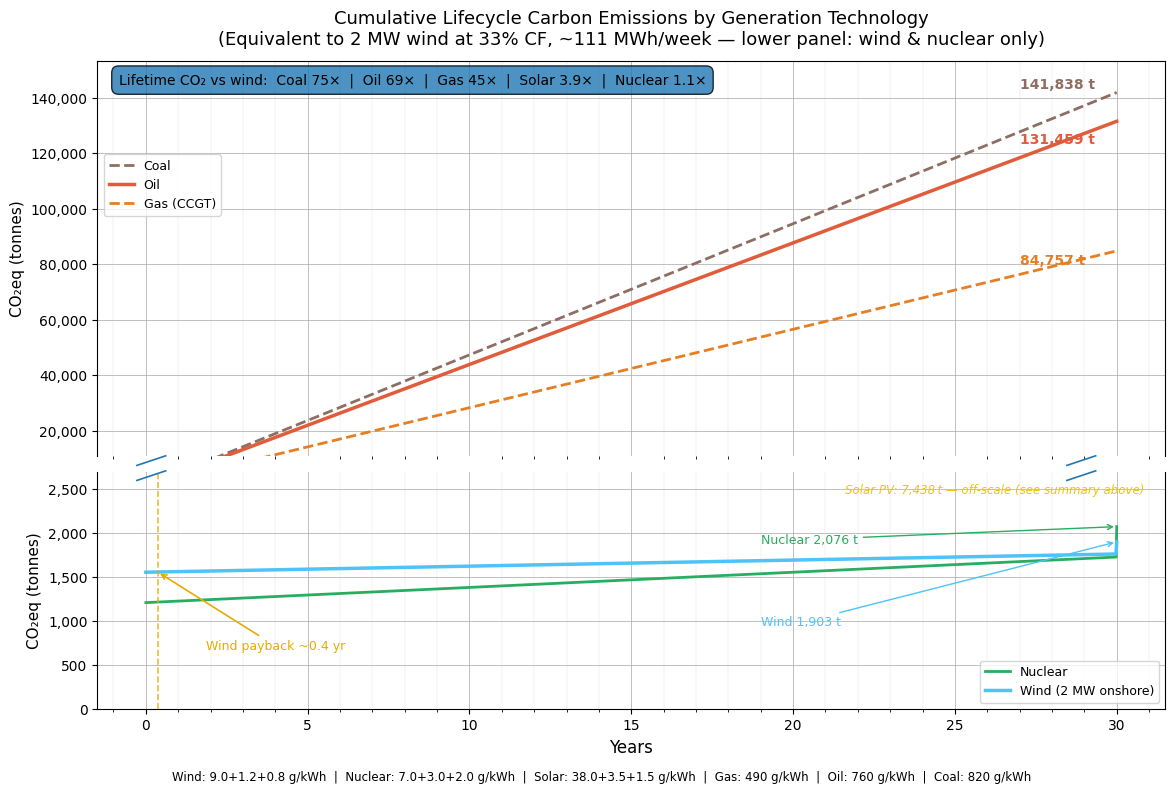

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

weekly_energy_mwh = TURBINE_CAPACITY_MW * CAPACITY_FACTOR * HOURS_PER_WEEK
lifetime_energy_mwh = weekly_energy_mwh * WEEKS

weeks = np.arange(0, WEEKS + 1)

# --- Cumulative carbon series (kg) ---

# Wind: large upfront manufacturing debt, small ongoing O&M, decommissioning at end
wind_cumulative = (
    WIND_MANUFACTURING_KG_PER_MWH * lifetime_energy_mwh
    + WIND_OM_KG_PER_MWH * weekly_energy_mwh * weeks
)
wind_cumulative[WEEKS] += WIND_DECOMM_KG_PER_MWH * lifetime_energy_mwh

# Oil, Gas, Coal: purely operational — no significant upfront carbon cost
oil_cumulative = OIL_KG_PER_MWH * weekly_energy_mwh * weeks
gas_cumulative = GAS_KG_PER_MWH * weekly_energy_mwh * weeks
coal_cumulative = COAL_KG_PER_MWH * weekly_energy_mwh * weeks

# Nuclear: upfront construction debt, ongoing O&M, decommissioning at end
nuclear_cumulative = (
    NUCLEAR_CONSTRUCTION_KG_PER_MWH * lifetime_energy_mwh
    + NUCLEAR_OM_KG_PER_MWH * weekly_energy_mwh * weeks
)
nuclear_cumulative[WEEKS] += NUCLEAR_DECOMM_KG_PER_MWH * lifetime_energy_mwh

# Solar PV: upfront manufacturing debt, ongoing O&M, end-of-life disposal
solar_cumulative = (
    SOLAR_MANUFACTURING_KG_PER_MWH * lifetime_energy_mwh
    + SOLAR_OM_KG_PER_MWH * weekly_energy_mwh * weeks
)
solar_cumulative[WEEKS] += SOLAR_DECOMM_KG_PER_MWH * lifetime_energy_mwh

# Convert to tonnes
wind_t = wind_cumulative / 1000
oil_t = oil_cumulative / 1000
gas_t = gas_cumulative / 1000
coal_t = coal_cumulative / 1000
nuclear_t = nuclear_cumulative / 1000
solar_t = solar_cumulative / 1000

years_axis = weeks / 52

# Wind carbon payback vs oil
above = np.where(oil_t > wind_t)[0]
payback_week = int(above[0]) if len(above) > 0 else None
payback_years = payback_week / 52 if payback_week else None

print(f"coal_t[-1]:    {coal_t[-1]:>10,.0f} t")
print(f"oil_t[-1]:     {oil_t[-1]:>10,.0f} t")
print(f"gas_t[-1]:     {gas_t[-1]:>10,.0f} t")
print(f"solar_t[-1]:   {solar_t[-1]:>10,.0f} t")
print(f"nuclear_t[-1]: {nuclear_t[-1]:>10,.0f} t")
print(f"wind_t[-1]:    {wind_t[-1]:>10,.0f} t")
print(f"payback_years: {payback_years:.2f}" if payback_years else "no payback found")

# --- Broken y-axis ---
# Top panel: coal, oil, gas (high-emission, linear scale)
# Bottom panel: wind, nuclear only — solar (~7,500 t) excluded to show wind/nuclear clearly
low_max = max(wind_t.max(), nuclear_t.max())
y_bot_max = low_max * 1.3
y_top_max = coal_t.max() * 1.08
# gap sits above solar so it falls in neither panel
y_top_min = max(solar_t.max() * 1.4, y_bot_max * 4.0)

COLOR_COAL = "#8d6e63"
COLOR_OIL = "#e05c3a"
COLOR_GAS = "#e67e22"
COLOR_WIND = "#4fc3f7"
COLOR_NUCLEAR = "#27ae60"
COLOR_SOLAR = "#f1c40f"

fig, (ax_top, ax_bot) = plt.subplots(
    2,
    1,
    sharex=True,
    figsize=(12, 8),
    gridspec_kw={"height_ratios": [2.5, 1.5], "hspace": 0.05},
)

# Top panel: fossil fuels only
ax_top.grid(True, linewidth=0.7, alpha=0.8)
ax_top.grid(True, which="minor", linewidth=0.3, alpha=0.4)
ax_top.plot(
    years_axis, coal_t, color=COLOR_COAL, linewidth=2.0, linestyle="--", label="Coal"
)
ax_top.plot(years_axis, oil_t, color=COLOR_OIL, linewidth=2.5, label="Oil")
ax_top.plot(
    years_axis,
    gas_t,
    color=COLOR_GAS,
    linewidth=2.0,
    linestyle="--",
    label="Gas (CCGT)",
)

# Bottom panel: wind and nuclear only (solar is off-scale for both panels)
ax_bot.grid(True, linewidth=0.7, alpha=0.8)
ax_bot.grid(True, which="minor", linewidth=0.3, alpha=0.4)
ax_bot.plot(years_axis, nuclear_t, color=COLOR_NUCLEAR, linewidth=2.0, label="Nuclear")
ax_bot.plot(
    years_axis, wind_t, color=COLOR_WIND, linewidth=2.5, label="Wind (2 MW onshore)"
)

ax_top.set_ylim(y_top_min, y_top_max)
ax_bot.set_ylim(0, y_bot_max)

ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(bottom=False)

# Diagonal break marks
d = 0.012
kwargs = dict(transform=fig.transFigure, clip_on=False, linewidth=1.2)
pos_top = ax_top.get_position()
pos_bot = ax_bot.get_position()
y_break_top = pos_top.y0
y_break_bot = pos_bot.y1
for x in (pos_top.x0, pos_top.x1):
    fig.lines.extend(
        [
            plt.Line2D(
                [x - d, x + d], [y_break_top - d * 0.5, y_break_top + d * 0.5], **kwargs
            ),
            plt.Line2D(
                [x - d, x + d], [y_break_bot - d * 0.5, y_break_bot + d * 0.5], **kwargs
            ),
        ]
    )

# Wind payback marker on bottom panel
if payback_years:
    ax_bot.axvline(
        x=payback_years, color="#e6ac00", linewidth=1.2, linestyle="--", alpha=0.8
    )
    ax_bot.annotate(
        f"Wind payback ~{payback_years:.1f} yr",
        xy=(payback_years, wind_t[payback_week]),
        xytext=(payback_years + 1.5, y_bot_max * 0.25),
        color="#e6ac00",
        fontsize=9,
        arrowprops=dict(arrowstyle="->", color="#e6ac00", lw=1.2),
    )

# End labels — top panel (coal, oil, gas)
ax_top.annotate(
    f"{coal_t[-1]:,.0f} t",
    xy=(30, coal_t[-1]),
    xytext=(27.0, coal_t[-1] * 1.01),
    color=COLOR_COAL,
    fontsize=10,
    fontweight="bold",
)
ax_top.annotate(
    f"{oil_t[-1]:,.0f} t",
    xy=(30, oil_t[-1]),
    xytext=(27.0, oil_t[-1] * 0.94),
    color=COLOR_OIL,
    fontsize=10,
    fontweight="bold",
)
ax_top.annotate(
    f"{gas_t[-1]:,.0f} t",
    xy=(30, gas_t[-1]),
    xytext=(27.0, gas_t[-1] * 0.94),
    color=COLOR_GAS,
    fontsize=10,
    fontweight="bold",
)

# End labels — bottom panel (wind and nuclear; solar is off-scale)
ax_bot.annotate(
    f"Nuclear {nuclear_t[-1]:,.0f} t",
    xy=(30, nuclear_t[-1]),
    xytext=(19.0, y_bot_max * 0.70),
    color=COLOR_NUCLEAR,
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color=COLOR_NUCLEAR, lw=1.0),
)
ax_bot.annotate(
    f"Wind {wind_t[-1]:,.0f} t",
    xy=(30, wind_t[-1]),
    xytext=(19.0, y_bot_max * 0.35),
    color=COLOR_WIND,
    fontsize=9,
    arrowprops=dict(arrowstyle="->", color=COLOR_WIND, lw=1.0),
)
ax_bot.text(
    0.98,
    0.95,
    f"Solar PV: {solar_t[-1]:,.0f} t — off-scale (see summary above)",
    transform=ax_bot.transAxes,
    ha="right",
    va="top",
    fontsize=8.5,
    color=COLOR_SOLAR,
    style="italic",
)

# Summary callout
ax_top.text(
    0.02,
    0.97,
    f"Lifetime CO\u2082 vs wind:  "
    f"Coal {coal_t[-1] / wind_t[-1]:.0f}\u00d7  |  Oil {oil_t[-1] / wind_t[-1]:.0f}\u00d7  |  Gas {gas_t[-1] / wind_t[-1]:.0f}\u00d7  |  "
    f"Solar {solar_t[-1] / wind_t[-1]:.1f}\u00d7  |  Nuclear {nuclear_t[-1] / wind_t[-1]:.1f}\u00d7",
    transform=ax_top.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.5", alpha=0.8),
)

# Axis labels and formatting
ax_top.set_ylabel("CO\u2082eq (tonnes)", fontsize=11)
ax_bot.set_ylabel("CO\u2082eq (tonnes)", fontsize=11)
ax_bot.set_xlabel("Years", fontsize=12)
ax_top.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax_bot.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax_bot.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax_bot.xaxis.set_minor_locator(ticker.MultipleLocator(1))

ax_top.set_title(
    f"Cumulative Lifecycle Carbon Emissions by Generation Technology\n"
    f"(Equivalent to 2 MW wind at 33% CF, ~{weekly_energy_mwh:.0f} MWh/week — lower panel: wind & nuclear only)",
    fontsize=13,
    pad=12,
)

ax_top.legend(fontsize=9, loc="upper left", bbox_to_anchor=(0.0, 0.78))
ax_bot.legend(fontsize=9, loc="lower right")

fig.text(
    0.5,
    0.01,
    f"Wind: {WIND_MANUFACTURING_KG_PER_MWH}+{WIND_OM_KG_PER_MWH}+{WIND_DECOMM_KG_PER_MWH} g/kWh  |  "
    f"Nuclear: {NUCLEAR_CONSTRUCTION_KG_PER_MWH}+{NUCLEAR_OM_KG_PER_MWH}+{NUCLEAR_DECOMM_KG_PER_MWH} g/kWh  |  "
    f"Solar: {SOLAR_MANUFACTURING_KG_PER_MWH}+{SOLAR_OM_KG_PER_MWH}+{SOLAR_DECOMM_KG_PER_MWH} g/kWh  |  "
    f"Gas: {GAS_KG_PER_MWH:.0f} g/kWh  |  Oil: {OIL_KG_PER_MWH:.0f} g/kWh  |  Coal: {COAL_KG_PER_MWH:.0f} g/kWh",
    ha="center",
    fontsize=8.5,
)

plt.subplots_adjust(left=0.08, right=0.97, top=0.91, bottom=0.10, hspace=0.05)

Lifetime wind intensity:    11.00 g/kWh
Lifetime nuclear intensity: 12.00 g/kWh
Lifetime solar intensity:   43.00 g/kWh
Gas (constant):             490.00 g/kWh
Oil (constant):             760.00 g/kWh


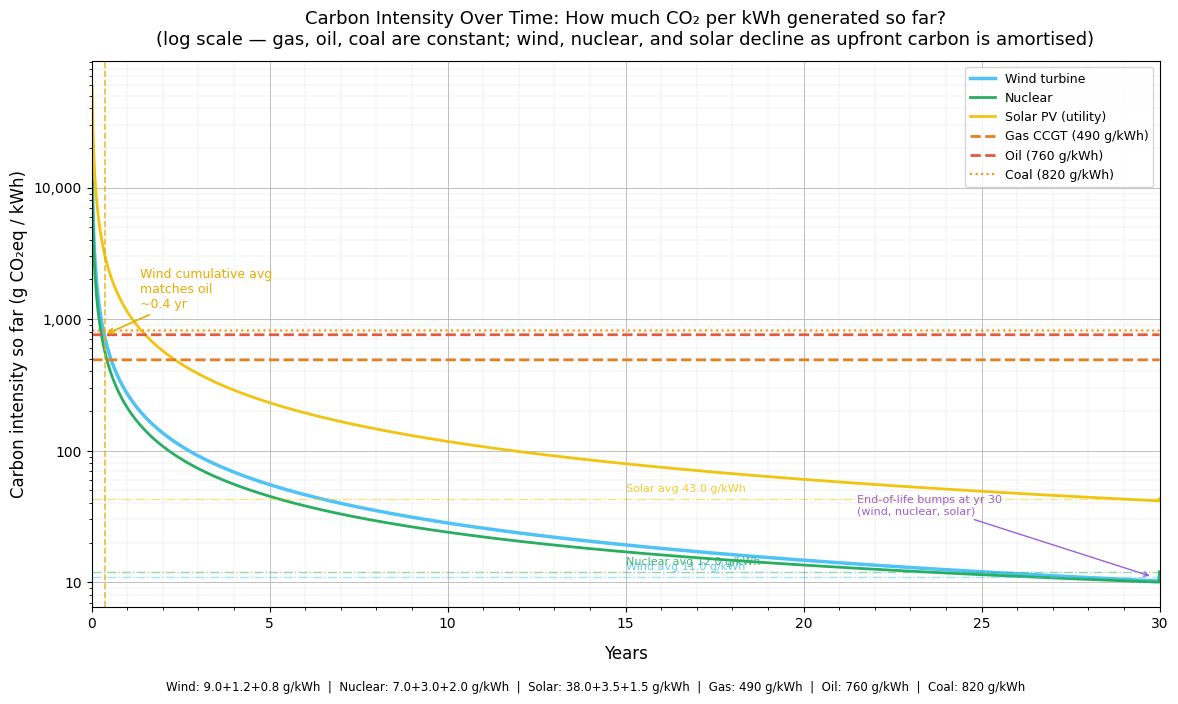

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

weekly_energy_mwh = TURBINE_CAPACITY_MW * CAPACITY_FACTOR * HOURS_PER_WEEK
lifetime_energy_mwh = weekly_energy_mwh * WEEKS

weeks = np.arange(0, WEEKS + 1)

# --- Cumulative carbon series (kg) ---

wind_cumulative_kg = (
    WIND_MANUFACTURING_KG_PER_MWH * lifetime_energy_mwh
    + WIND_OM_KG_PER_MWH * weekly_energy_mwh * weeks
)
wind_cumulative_kg[WEEKS] += WIND_DECOMM_KG_PER_MWH * lifetime_energy_mwh

nuclear_cumulative_kg = (
    NUCLEAR_CONSTRUCTION_KG_PER_MWH * lifetime_energy_mwh
    + NUCLEAR_OM_KG_PER_MWH * weekly_energy_mwh * weeks
)
nuclear_cumulative_kg[WEEKS] += NUCLEAR_DECOMM_KG_PER_MWH * lifetime_energy_mwh

solar_cumulative_kg = (
    SOLAR_MANUFACTURING_KG_PER_MWH * lifetime_energy_mwh
    + SOLAR_OM_KG_PER_MWH * weekly_energy_mwh * weeks
)
solar_cumulative_kg[WEEKS] += SOLAR_DECOMM_KG_PER_MWH * lifetime_energy_mwh

# Cumulative energy generated (MWh) — used as denominator for intensity
cumulative_energy_mwh = weekly_energy_mwh * weeks

# Carbon intensity so far (g CO2eq/kWh == kg/MWh); undefined at week 0 (no energy yet)
with np.errstate(divide="ignore", invalid="ignore"):

    def _intensity(kg):
        return np.where(cumulative_energy_mwh > 0, kg / cumulative_energy_mwh, np.nan)

    wind_intensity = _intensity(wind_cumulative_kg)
    nuclear_intensity = _intensity(nuclear_cumulative_kg)
    solar_intensity = _intensity(solar_cumulative_kg)

# Gas, oil, and coal are constant throughout (no upfront manufacturing credit amortised)
# Their "intensity so far" equals their operational intensity at every point in time.

years_axis = weeks / 52

lifetime_wind_intensity = wind_cumulative_kg[WEEKS] / lifetime_energy_mwh
lifetime_nuclear_intensity = nuclear_cumulative_kg[WEEKS] / lifetime_energy_mwh
lifetime_solar_intensity = solar_cumulative_kg[WEEKS] / lifetime_energy_mwh

print(f"Lifetime wind intensity:    {lifetime_wind_intensity:.2f} g/kWh")
print(f"Lifetime nuclear intensity: {lifetime_nuclear_intensity:.2f} g/kWh")
print(f"Lifetime solar intensity:   {lifetime_solar_intensity:.2f} g/kWh")
print(f"Gas (constant):             {GAS_KG_PER_MWH:.2f} g/kWh")
print(f"Oil (constant):             {OIL_KG_PER_MWH:.2f} g/kWh")

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 7))

COLOR_OIL = "#e05c3a"
COLOR_GAS = "#e67e22"
COLOR_COAL = "#ff8f00"
COLOR_WIND = "#4fc3f7"
COLOR_NUCLEAR = "#27ae60"
COLOR_SOLAR = "#f1c40f"

# Declining intensity curves for technologies with upfront carbon debt (plot from week 1)
ax.semilogy(
    years_axis[1:],
    wind_intensity[1:],
    color=COLOR_WIND,
    linewidth=2.5,
    label="Wind turbine",
)
ax.semilogy(
    years_axis[1:],
    nuclear_intensity[1:],
    color=COLOR_NUCLEAR,
    linewidth=2.0,
    label="Nuclear",
)
ax.semilogy(
    years_axis[1:],
    solar_intensity[1:],
    color=COLOR_SOLAR,
    linewidth=2.0,
    label="Solar PV (utility)",
)

# Constant horizontal lines for operational-only sources
ax.semilogy(
    years_axis[1:],
    np.full(WEEKS, GAS_KG_PER_MWH),
    color=COLOR_GAS,
    linewidth=2.0,
    linestyle="--",
    label=f"Gas CCGT ({GAS_KG_PER_MWH:.0f} g/kWh)",
)
ax.semilogy(
    years_axis[1:],
    np.full(WEEKS, OIL_KG_PER_MWH),
    color=COLOR_OIL,
    linewidth=2.0,
    linestyle="--",
    label=f"Oil ({OIL_KG_PER_MWH:.0f} g/kWh)",
)
ax.semilogy(
    years_axis[1:],
    np.full(WEEKS, COAL_KG_PER_MWH),
    color=COLOR_COAL,
    linewidth=1.5,
    linestyle=":",
    label=f"Coal ({COAL_KG_PER_MWH:.0f} g/kWh)",
)

# Lifetime average reference lines
for val, color, label in [
    (
        lifetime_wind_intensity,
        COLOR_WIND,
        f"Wind avg {lifetime_wind_intensity:.1f} g/kWh",
    ),
    (
        lifetime_nuclear_intensity,
        COLOR_NUCLEAR,
        f"Nuclear avg {lifetime_nuclear_intensity:.1f} g/kWh",
    ),
    (
        lifetime_solar_intensity,
        COLOR_SOLAR,
        f"Solar avg {lifetime_solar_intensity:.1f} g/kWh",
    ),
]:
    ax.axhline(y=val, color=color, linewidth=1.0, linestyle="-.", alpha=0.5)
    ax.text(
        0.5,
        val * 1.13,
        label,
        color=color,
        fontsize=8,
        alpha=0.85,
        transform=ax.get_yaxis_transform(),
    )

# Mark where wind cumulative intensity first drops below oil
crossover = next((w for w in weeks[1:] if wind_intensity[w] <= OIL_KG_PER_MWH), None)
if crossover:
    crossover_yr = crossover / 52
    ax.axvline(
        x=crossover_yr, color="#e6ac00", linewidth=1.2, linestyle="--", alpha=0.8
    )
    ax.annotate(
        f"Wind cumulative avg\nmatches oil\n~{crossover_yr:.1f} yr",
        xy=(crossover_yr, OIL_KG_PER_MWH),
        xytext=(crossover_yr + 1.0, OIL_KG_PER_MWH * 1.6),
        color="#e6ac00",
        fontsize=9,
        arrowprops=dict(arrowstyle="->", color="#e6ac00", lw=1.2),
    )

# Decommissioning blips at year 30 (wind, nuclear, solar all show a small uptick)
ax.annotate(
    "End-of-life bumps at yr 30\n(wind, nuclear, solar)",
    xy=(29.8, wind_intensity[WEEKS]),
    xytext=(21.5, lifetime_wind_intensity * 3.0),
    color="#9c5fd6",
    fontsize=8,
    arrowprops=dict(arrowstyle="->", color="#9c5fd6", lw=1.0),
)

ax.set_xlabel("Years", fontsize=12, labelpad=10)
ax.set_ylabel("Carbon intensity so far (g CO\u2082eq / kWh)", fontsize=12)
ax.set_title(
    "Carbon Intensity Over Time: How much CO\u2082 per kWh generated so far?\n"
    "(log scale — gas, oil, coal are constant; wind, nuclear, and solar decline as upfront carbon is amortised)",
    fontsize=13,
    pad=12,
)
ax.set_xlim(0, 30)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.grid(True, linewidth=0.7, alpha=0.8)
ax.grid(True, which="minor", linewidth=0.3, alpha=0.4)
ax.legend(fontsize=9, loc="upper right")

fig.text(
    0.5,
    0.01,
    f"Wind: {WIND_MANUFACTURING_KG_PER_MWH}+{WIND_OM_KG_PER_MWH}+{WIND_DECOMM_KG_PER_MWH} g/kWh  |  "
    f"Nuclear: {NUCLEAR_CONSTRUCTION_KG_PER_MWH}+{NUCLEAR_OM_KG_PER_MWH}+{NUCLEAR_DECOMM_KG_PER_MWH} g/kWh  |  "
    f"Solar: {SOLAR_MANUFACTURING_KG_PER_MWH}+{SOLAR_OM_KG_PER_MWH}+{SOLAR_DECOMM_KG_PER_MWH} g/kWh  |  "
    f"Gas: {GAS_KG_PER_MWH:.0f} g/kWh  |  Oil: {OIL_KG_PER_MWH:.0f} g/kWh  |  Coal: {COAL_KG_PER_MWH:.0f} g/kWh",
    ha="center",
    fontsize=8.5,
)

plt.subplots_adjust(left=0.08, right=0.97, top=0.91, bottom=0.13)

## Wind vs Nuclear: A Closer Look

The charts show wind sitting *above* nuclear for almost the entire 30-year period, yet nuclear ends up with a *higher* lifetime total. This apparent contradiction is worth unpacking.

### Why wind appears above nuclear on the charts

Both technologies carry an upfront manufacturing carbon debt, but the composition differs:

| Phase                                  | Wind           | Nuclear        |
|----------------------------------------|----------------|----------------|
| Upfront (manufacturing / construction) | 9.0 g/kWh      | 7.0 g/kWh      |
| Ongoing O&M                            | 1.2 g/kWh      | 3.0 g/kWh      |
| End-of-life                            | 0.8 g/kWh      | 2.0 g/kWh      |
| **Lifetime total**                     | **11.0 g/kWh** | **12.0 g/kWh** |

Wind's larger upfront debt (~1,557 t vs nuclear's ~1,211 t) means it starts higher and remains above nuclear throughout the operational life. Nuclear's higher ongoing O&M rate closes the gap steadily — by year 30, the two are only ~35 t apart. Then nuclear's much larger decommissioning cost (+346 t vs wind's +138 t) flips it above wind in the final accounting. The "crossing point" is effectively at the decommissioning step, not during operations.

### Nuclear decommissioning is genuinely uncertain

The 2.0 g/kWh figure used for nuclear end-of-life covers physical plant dismantling and long-term spent fuel management. Unlike wind decommissioning (which largely follows established practice and recovers ~90% of structural steel), nuclear decommissioning has significant uncertainties:

- **Timescale**: full decommissioning of a nuclear plant typically takes 40–60 years post-shutdown, with regulatory and funding risks throughout.
- **Spent fuel**: no country has yet commissioned a permanent geological repository for high-level radioactive waste. Long-term disposal costs are still being estimated.
- **Historical underestimation**: several UK and US decommissioning projects have come in substantially over their original cost estimates.

If the true end-of-life cost is higher than 2.0 g/kWh, nuclear's lifetime total grows accordingly — widening its gap over wind.

### The IPCC range for nuclear is uniquely wide

The IPCC AR5 lifecycle range for nuclear is **3.7–110 g CO₂eq/kWh** — far wider than wind (7–20) or solar (18–180). The two biggest drivers of this spread are:

1. **Uranium enrichment method**: gaseous diffusion enrichment (used in older US and UK plants) consumes roughly 50× more electricity than modern centrifuge enrichment. At the grid carbon intensities typical when those plants were built, this dominates the lifecycle total. Centrifuge-enriched nuclear (France, most modern plants) comes in around 4–8 g/kWh; diffusion-enriched plants can exceed 40 g/kWh.

2. **Grid carbon intensity at build time**: the embodied carbon in steel, concrete, and components depends on the electricity grid when the plant was constructed.

The 12 g/kWh median used in this model is appropriate for a modern Western reactor using centrifuge enrichment. Using 6 g/kWh (a reasonable figure for French-style nuclear) would place nuclear clearly below wind for the entire 30-year period. Using 20–25 g/kWh (diffusion-enriched, older grid) would place it well above wind.

### Bottom line on wind vs nuclear

At the NREL/IPCC central estimates used here, the two technologies are effectively **carbon-equivalent** — 11 vs 12 g CO₂eq/kWh lifetime, a difference smaller than the uncertainty in either figure. Both are roughly 40–70× lower than gas and oil. The more practically significant difference between them is not lifecycle carbon but rather construction time, cost, water use, land use, and grid dispatchability.

## The Landman Monologue: Claims and Evidence

> *Landman* (Paramount+, 2024), Season 1 Episode 3 — "Hell Has a Front Yard". Character Tommy Norris, standing next to a wind turbine:

> *"Do you have any idea how much diesel they have to burn to mix that much concrete or make that steel and haul this shit out here and put it together with a 450 foot crane? You wanna guess how much oil it takes to lubricate that thing or winterize it? In its 20-year lifespan it won't offset the carbon footprint of making it.*
>
> *And don't even get me started on solar panels and the lithium in your Tesla battery. And never mind the fact that if the whole world decided to go electric tomorrow, we don't have the transmission lines to get the electricity to the cities. It would take 30 years if we started tomorrow. And unfortunately for your grandkids, we have a 120-year petroleum-based infrastructure. Our whole lives depend on it.*
>
> *Hell, it's in everything… that road we came in on, the wheels on every car ever made, including yours, tennis rackets, lipstick, refrigerators antihistamines, anything plastic, your cell phone case, artificial heart valves, any kind of clothing that's not made with animal or plant fibers, soap, hand lotion, garbage bags, fishing boats, you name it… every fucking thing. And you know what the kicker is… we're gonna run out before we find a replacement.*
>
> *And believe me, if Exxon thought them fucking things were the future, they'd be putting them all over the goddamn place. Getting oil out of the ground is the most dangerous job in the world, we don't do it because we like it, we do it because we've run out of options. And you're out here trying to find something to blame for the danger besides your boss. There ain't nobody to blame but the demand that we keep pumping it."*

The monologue makes eight distinct claims. Each is examined below.

---

### Claim 1: "In its 20-year lifespan, it won't offset the carbon footprint of making it"

**False — off by a factor of roughly 50.**

This is the central claim and the primary subject of this notebook. The manufacturing carbon debt of a 2 MW onshore wind turbine (~1,560 t CO₂eq) is repaid in **4–5 months** of operation against oil, not 20 years. The turbine then spends ~98–99% of its operational life in net carbon credit. A 2024 lifecycle assessment of the real-world Harapaki wind farm (41 turbines) found a carbon payback period of **1.5–1.7 years** against gas — even under that more conservative framing, the claim is wrong by an order of magnitude (ref 12).

The full breakdown is shown in the charts above.

---

### Claim 2: "Don't get me started on solar panels"

**Misleading — solar manufacturing is energy-intensive, but lifetime emissions are still ~11× lower than gas, and the materials are recyclable.**

Solar PV does carry a large upfront manufacturing carbon cost, dominated by the energy intensity of silicon purification and cell fabrication. The NREL harmonised median for utility-scale crystalline silicon is **~43 g CO₂eq/kWh** lifetime — roughly 4× higher than wind, and the manufacturing phase accounts for ~88% of that total (ref 9).

That said, 43 g/kWh is still:

- ~11× lower than gas (490 g/kWh)
- ~17× lower than oil (760 g/kWh)
- ~19× lower than coal (820 g/kWh)

The manufacturing footprint is real and worth knowing. Panels made on coal-heavy grids (primarily China) carry higher embodied carbon than those made in Europe or the US — this is a legitimate reason to care about *where* panels are made. It is not a reason to conclude solar is comparable to fossil fuels.

**Solar panels are recyclable, though current commercial practice recovers materials unevenly.** Aluminium frames and copper wiring are readily recovered by standard recyclers. Glass, which makes up ~75% of panel weight, is recoverable but is often downcycled to construction aggregate rather than closed-loop reuse. Full recovery of the silicon wafer and silver contacts — the highest-value materials — requires specialised chemical processes; these are commercially available from specialist recyclers and can achieve >95% material recovery (EPA; ScienceDirect 2023), but are not yet standard practice at scale. The EU's WEEE directive mandates panel collection and treatment, and both recycling capacity and recovery rates are improving rapidly as the first large cohorts of 1990s–2000s panels reach end of life. This is structurally different from combusting fossil fuels, where the energy content is irreversibly destroyed and nothing material is recovered.

---

### Claim 3: "The lithium in your Tesla battery"

**Misleading — battery manufacturing adds upfront emissions, but EV lifecycle emissions are 66–70% lower than gasoline cars, and battery minerals are recoverable.**

Lithium-ion battery manufacturing does have a significant carbon footprint, dominated by cell fabrication and raw material processing (lithium, nickel, cobalt). Current production emits roughly 54–115 kg CO₂eq per kWh of battery capacity depending on cathode chemistry and the carbon intensity of the manufacturing grid — so a 75 kWh pack carries roughly 4–9 tonnes CO₂eq (Nature Communications, 2024, ref 15).

This is a real upfront cost. However:

- The manufacturing carbon breakeven point — where cumulative EV emissions fall below a comparable gasoline car — occurs at roughly **2–4 years** of typical use (ICCT 2024, ref 14).
- Over a full vehicle lifetime, lifecycle emissions of a model year 2024 BEV sedan in the US are **66–70% lower** than a conventional gasoline vehicle, and 71–74% lower for SUVs (ICCT 2024, ref 14).
- This advantage will grow as the electricity grid decarbonises further.

**Crucially, battery minerals are not consumed during use.** Lithium, cobalt, and nickel are not burned or depleted in the electrochemical cycle — they remain in the pack at end of life and can be recovered. Advanced hydrometallurgical recycling achieves >90% recovery of cobalt and nickel commercially, and up to ~92% for lithium in leading operations (with laboratory processes exceeding 95%); overall material recovery ranges from 25–96% depending on process and battery chemistry (Nature Communications 2024, ref 15). Recycled materials carry a materially lower carbon footprint than virgin extraction. This is structurally different from fossil fuels, where the fuel is irreversibly combusted and lost.

The structure of the argument — manufacturing has a carbon cost, therefore the technology is bad — is the same reasoning applied (incorrectly) to wind turbines in Claim 1. It conflates upfront cost with lifetime cost, and ignores that the materials can be recovered and reused.

---

### Claim 4: "We don't have the transmission lines to get the electricity to the cities. It would take 30 years if we started tomorrow"

**Partially true as an engineering observation; false as a conclusion — and self-undermining given the source.**

The US transmission grid genuinely needs substantial expansion. The DOE's National Transmission Planning Study (2024) found the contiguous US transmission system will need to **at least double in size by 2050** to support a clean energy transition at least cost. Around 70% of existing transmission lines are over 25 years old. Permitting, regulatory complexity, and local opposition are real bottlenecks that slow new line construction.

However, the claim conflates a genuine infrastructure challenge with an argument against transition:

- Grid expansion is an **argument for investment**, not an argument that electrification is futile. The solution to "we need more transmission" is to build more transmission.
- The US has been building and upgrading grid infrastructure continuously; this is not a novel problem requiring 30 years to start.
- The timeline for grid expansion and the timeline for deploying renewables are **parallel processes**, not sequential ones. Renewables already feed into the existing grid today.
- Countries with far smaller economies and fewer engineering resources have managed rapid grid expansion within a decade.

The "30 years" figure has no published basis. The claim is better read as "grid expansion is hard and slow" — which is true — than as "electrification cannot happen," which is not supported.

**There is also a deeper irony here.** This grid buildout *could have started 20 years ago*. Wind and solar were already commercially viable by the early 2000s, and the case for modernising transmission infrastructure was well understood. What slowed that process was not engineering infeasibility but a sustained, well-funded campaign of doubt and delay. Peer-reviewed research has documented this in detail: Supran & Oreskes (2017) found that ExxonMobil's internal documents acknowledged human-caused climate change in 83% of cases, while 81% of its public-facing advertisements sowed doubt about that same science (ref 17). A subsequent *Science* study (Supran, Rahmstorf & Oreskes 2023) showed ExxonMobil's own scientists accurately projected global warming decades in advance — projections that were contradicted by the company's public messaging (ref 18). A PLOS One analysis of BP, Chevron, ExxonMobil, and Shell (2022) found that across a 12-year period, all four companies' actual capital allocation to clean energy was negligible compared to their public climate pledges — with ExxonMobil generating zero clean energy over the decade studied (ref 16). The same industry that spent decades slowing the transition now points to the resulting delay as evidence the transition cannot happen. The "30 years" problem, to the extent it exists, is substantially a consequence of the disinformation it is being used to justify.

---

### Claim 5: "If Exxon thought them fucking things were the future, they'd be putting them all over the goddamn place"

**False — oil companies did invest in renewables, and some still do.**

This argument treats lack of fossil fuel investment as evidence that renewables don't work. The historical record contradicts it on both counts:

- **Exxon (then Esso/Standard Oil) invested directly in solar PV research and manufacturing in the 1970s**, during the energy crisis. The company helped develop early solar cell technology and ran public advertising about its solar work (NPR, 2019).
- **Exxon signed the largest renewable energy power purchase agreement in oil industry history in 2018** — 500 MW of wind and solar in the Permian Basin — specifically to power its own oil extraction operations at lower cost.
- BP, Shell, and other majors made large renewable energy investments in the 2000s–2010s before partially retreating when fossil fuel profitability recovered. BP at one point rebranded as "Beyond Petroleum."

The reason major US oil companies like ExxonMobil have not scaled up wind and solar as core businesses is straightforwardly **economic**: oil and gas generate far higher returns on capital than utility-scale renewables, and their existing asset base, supply chains, and expertise are in hydrocarbons. The PLOS One analysis (2022) found a consistent mismatch between public climate pledges and actual investment — ExxonMobil generated no clean energy whatsoever during the 2009–2020 study period (ref 16).

The "Exxon test" proves the opposite of what the monologue implies: oil companies have tried renewables, found them less profitable than fossil fuels in the near term, and prioritised accordingly. That is a statement about profit incentives, not about whether the technology works.

---

### Claim 6: "It's in everything… every fucking thing"

**True but irrelevant to energy policy — and an argument for using less oil as fuel, not more.**

The list is accurate. Petroleum is the feedstock for most plastics, synthetic rubbers, lubricants, many pharmaceuticals, and a wide range of industrial chemicals. Lipstick, artificial heart valves, and antihistamines do contain petroleum-derived compounds. Tyres on electric vehicles are made of synthetic rubber derived from oil. This is not in dispute.

The argument, however, is a **straw man**. No credible advocate for renewable energy argues that oil should be banned entirely or that all petroleum-derived products should be eliminated. The policy debate is about whether oil should be *burned for energy* — which accounts for the overwhelming majority of consumption — not whether it should be used as a manufacturing feedstock.

The numbers are instructive: approximately **91–93% of global oil consumption is burned as fuel** (transport, heating, power generation). Only **7–9% goes to petrochemical feedstocks** — the plastics, pharmaceuticals, and synthetic materials on the list (IEA World Energy Outlook). The manufacturing uses Tommy cites represent a small fraction of the total.

This matters because **the "running out" problem is solved by not burning it for energy.** If oil consumption for fuel were displaced by renewable energy, the same oil reserves that would otherwise be exhausted in 50–60 years would last several centuries for manufacturing purposes. Switching to electric vehicles and renewable power does not threaten artificial heart valves or antihistamines — it protects the raw material supply for them by dramatically reducing the rate of depletion. The monologue implicitly treats oil consumption as one undifferentiated pool; the reality is that energy combustion and chemical feedstock use are separate problems with separable solutions.

The argument also misrepresents the scale of petroleum dependency in manufacturing. Most of the items listed are **not irreplaceable by other materials in principle** — bio-based plastics, plant-derived lubricants, and bio-pharmaceutical synthesis routes exist or are in active development. This does not make the transition trivial, but it means "petroleum is used in products" is a reason for managed transition planning, not a reason to reject decarbonisation of energy.

---

### Claim 7: "We have a 120-year petroleum-based infrastructure. Our whole lives depend on it"

**True as a description; false as a conclusion.**

The observation is accurate. The modern global economy was built around cheap fossil fuels over the past century. Road networks, shipping lanes, building heating systems, industrial processes, and supply chains are all deeply entangled with oil and gas. That is not in question.

The inference — that this makes transition impossible or prohibitively disruptive — does not follow from the premise. Several reasons:

- **Infrastructure transitions have happened before, at comparable scale.** The shift from coal-gas street lighting to electric, from horse transport to motorised vehicles, from telegraph to telephone — all involved replacing century-scale infrastructure in the span of a few decades. The transition to oil itself displaced a coal-based economy that was similarly entrenched.
- **The transition is already underway.** In 2023, renewables accounted for over 90% of new electricity generation capacity added globally (IEA). The existing grid continues to function during the transition; replacement does not require the old system to stop before the new one starts.
- **"Our lives depend on it" conflates current dependence with permanent necessity.** Current dependence on petroleum infrastructure is a fact about how things are built today, not a claim about what is technically possible to change over 20–30 years.

The 120-year infrastructure argument is structurally a **momentum argument**: changing is hard because so much is already built. That is true of every major infrastructure transition. It is a reason to plan carefully and invest seriously. It is not evidence that the transition cannot succeed.

There is, however, a significant omission in this framing. The petroleum-based infrastructure did not persist simply because of engineering inertia — it was actively defended. The fossil fuel industry has spent decades lobbying against the policies and investment that would have accelerated the alternative infrastructure's development. The American Petroleum Institute ran coordinated campaigns against climate legislation throughout the 1990s and 2000s; ExxonMobil funded dozens of organisations casting doubt on climate science while its own researchers confirmed it internally (Supran & Oreskes, 2017, ref 17); and major oil companies' public pledges to invest in clean energy were systematically contradicted by their actual capital allocation (PLOS One, 2022, ref 16). The result is that the renewable and transmission infrastructure that could exist today is less developed than it would have been without that interference. The argument "the infrastructure isn't ready" therefore doubles as an indictment of the lobby that kept it that way — not a neutral observation about the difficulty of change.

---

### Claim 8: "We're gonna run out before we find a replacement"

**Self-refuting — renewable energy is the replacement, and switching to it is the fastest way to avoid running out.**

The claim acknowledges a real constraint: global petroleum reserves are finite. Conventional oil production may have already peaked or is projected to peak within the next 20–30 years depending on the scenario; unconventional reserves extend the timeline but at higher extraction cost and carbon intensity. The concern about depletion before alternatives are ready has been raised seriously since the 1970s (Club of Rome, Hubbert peak oil).

But the argument undermines itself in the context of the full monologue:

- Renewable electricity — wind, solar, hydro, nuclear — is already commercially deployed at scale. The "replacement" exists. It is not a future technology still being sought; it is the technology the monologue has been arguing against for the previous eight minutes.
- The fastest way to avoid running out of oil is to stop burning it for energy and preserve it for the chemical manufacturing uses the monologue itself identifies as irreplaceable. Decarbonising energy *solves* the depletion problem.
- Opposing renewable energy deployment on the grounds that "we'll run out of oil" is contradictory: it accelerates the depletion it warns about.

The logical structure is: *"We're running out of oil and haven't found a replacement — therefore we shouldn't use the replacement."* That is not a coherent argument. It is, at best, a failure to connect the concern about depletion with the available solution.

---

### On the Straw Man: "Advocating Renewables" Does Not Mean "Ban All Oil Immediately"

The monologue is most effective rhetorically because it conflates two different positions: the view that oil should not be burned for energy when cheaper and cleaner alternatives exist, and the position that oil should be prohibited entirely, all petrochemical products eliminated, and all existing infrastructure scrapped overnight.

No serious energy policy position holds the second view. The International Energy Agency's Net Zero by 2050 scenario, for example, explicitly includes continued oil and gas use for petrochemicals and hard-to-decarbonise industrial processes throughout the century — while phasing out combustion for power and transport. The argument that "oil is in everything, therefore we can't reduce oil combustion" is a non sequitur. The items on Tommy's list — lipstick, antihistamines, heart valves — are not threatened by replacing oil-fired power stations with wind turbines.

The monologue's rhetorical move is to take a list of genuinely important petroleum-dependent products, establish that their loss would be catastrophic, and then use that to argue against a policy that does not threaten them. This is a classic straw man: misrepresent the opposing argument as more extreme than it is, then knock down the misrepresentation.

---

### Summary

| Claim                                       | Verdict           | Key figure                                                                                           |
|---------------------------------------------|-------------------|------------------------------------------------------------------------------------------------------|
| Wind turbine won't pay back in 20 years     | **False**         | Payback ~4–5 months vs oil; ~1.5–1.7 years vs gas (refs 12, 13)                                      |
| Solar panels are a dirty technology         | **Misleading**    | 43 g/kWh lifetime — ~11× lower than gas; materials recyclable (refs 4, 9)                            |
| EV battery lithium offsets the benefit      | **Misleading**    | 66–70% lower lifetime emissions; minerals recoverable, not consumed (refs 14, 15)                    |
| 30 years to build enough transmission       | **Misleading**    | Real challenge; delay is itself a documented product of fossil fuel disinformation (refs 16, 17, 18) |
| Exxon would invest if renewables worked     | **False**         | Exxon has invested in solar and wind; retreat is driven by fossil fuel profitability (ref 16)        |
| "It's in everything" — oil is irreplaceable | **Straw man**     | Only 7–9% of oil goes to petrochemicals; renewables don't threaten those uses (IEA)                  |
| 120-year infrastructure locks us in         | **Misleading**    | Every infrastructure era has been replaced; transition is already underway (IEA 2023)                |
| We'll run out before finding a replacement  | **Self-refuting** | Renewables are the replacement; switching to them is the fastest way to avoid depletion              |

## Building Out the Energy Grid: Rates, Timelines, and an Action Plan

Claim 4 in the Landman monologue — "we don't have the transmission lines" — is the one claim that is **partly factually grounded**. The existing grid genuinely is insufficient to carry the power flows a fully renewable system requires. But the inference (that clean energy is therefore unworkable) inverts the logic: grid expansion is a solvable infrastructure problem, not an immutable physical constraint.

---

### Where We Stand

Global renewable capacity additions hit a record **666 GW in 2024** — solar alone accounted for 553 GW, more than triple the entire installed global nuclear fleet added in a single year (ref 21). The US added **48.6 GW** of new generating capacity in 2024, the largest single-year addition since 2002, led by utility-scale solar (30 GW) and grid-scale battery storage (10.3 GW, a record) (refs 20, 11).

| Technology                 | 2024 global additions | 2024 US additions              |
|----------------------------|-----------------------|--------------------------------|
| Solar PV                   | 553 GW                | ~47 GW (utility + distributed) |
| Wind                       | ~117 GW               | 5.1 GW                         |
| Grid-scale battery storage | ~50 GW (est.)         | 10.3 GW                        |
| **Total renewables**       | **~666 GW**           | **~48.6 GW**                   |

---

### What a 1.5°C Pathway Requires

The IEA's Net Zero by 2050 roadmap (ref 19) sets specific annual build targets needed by 2030:

| Technology             | Required by 2030 (global) | 2024 actual (global) | Status                             |
|------------------------|---------------------------|----------------------|------------------------------------|
| Solar PV               | 630 GW/yr                 | 553 GW               | 88% of target — nearly there       |
| Wind                   | 390 GW/yr                 | ~117 GW              | 30% of target — 3× scale-up needed |
| Grid-scale storage     | ~170 GW/yr by 2030        | ~50 GW (est.)        | 29% of target                      |
| Annual grid investment | USD ~900 bn/yr            | USD ~400 bn/yr       | 44% of target                      |

Solar is already close to the 2030 target. Wind is the critical gap. Storage is growing rapidly but from a low base. Annual grid investment (transmission and distribution) needs to more than double globally (ref 23).

---

### Historical Precedent

Rapid energy infrastructure buildout is not unprecedented:

- **Nuclear, 1970–1990**: After the 1973 oil shock, ~170 GW of nuclear came online globally in a single decade. At peak, a new reactor started up somewhere in the world every 17 days. The US alone installed ~95 GW of nuclear capacity between 1970 and 1990 — roughly 4.75 GW/yr averaged over 20 years (ref 25).
- **CCGT gas, 1990s–2000s**: Combined-cycle gas turbine orders grew from 3.9 GW/yr (1988) to 26 GW/yr (1994) in six years; roughly half the world's current CCGT fleet was built in a single decade.
- **Solar PV, 2010–2024**: Has gone from a niche technology to 553 GW of annual additions in 15 years — the fastest deployment of any energy technology in history.

The required wind and storage scale-up is large, but it sits within the historical range for energy transitions. Crucially, solar and wind manufacturing supply chains are already global and proven — unlike nuclear, which required bespoke heavy-engineering industries to be built from scratch.

---

### The Real Bottleneck: Transmission

The generation gap is closing. The transmission gap is not.

The DOE's **National Transmission Planning Study** (2024) — the most comprehensive US grid analysis to date — found that the lowest-cost path to clean electricity requires the US grid to **expand 2.1–2.6× by 2050**, with interregional transmission links specifically growing **1.9–3.5×** (ref 22). Yet the US currently adds only ~3,300 circuit-miles of new transmission per year, a pace that has barely changed since 2011.

Globally, annual grid investment reached USD ~400 billion in 2024 but needs to reach USD ~900 billion/yr to stay on track for net zero — a shortfall of USD ~500 billion annually (ref 23).

The bottleneck is **not technology or cost**. It is **permitting**: a new interstate transmission line in the US takes an average of 10–12 years from proposal to operation, largely due to fragmented federal/state authority and serial (rather than parallel) environmental review. FERC Order 1920 (May 2024) is the first significant federal reform in decades, requiring grid operators to plan proactively for future clean energy scenarios — but implementation will take years to flow through.

---

### Grid-Scale Storage

Storage is the mechanism by which intermittent solar and wind become a 24/7 supply. The IEA projects that net zero requires **~120 GW/yr of new storage additions globally through 2030**, rising to ~170 GW in the year 2030 itself, with batteries providing ~90% of new capacity (ref 24).

US grid-scale battery additions reached 10.3 GW in 2024 — a record. Storage costs have fallen ~90% since 2010. Current growth rates of ~25%/yr compounded would, if sustained, approach the required global scale by ~2028–2029.

---

### Realistic Timeline

| Milestone                    | Target year       | Current trajectory                           |
|------------------------------|-------------------|----------------------------------------------|
| Global solar: 630 GW/yr      | 2030 (IEA NZE)    | 553 GW in 2024 — likely achievable           |
| Global wind: 390 GW/yr       | 2030 (IEA NZE)    | 117 GW in 2023 — requires 3× scale-up        |
| US: 80% clean electricity    | 2035 (DOE target) | On track if wind and storage accelerate      |
| US grid: 2× current capacity | 2050 (DOE NTP)    | At risk without permitting reform            |
| Net zero global electricity  | 2050 (IEA NZE)    | Achievable with policy action; not automatic |

The 2035 US clean electricity target is achievable, but US wind additions need to recover from the 2024 dip (5.1 GW — a 10-year low driven by supply chain and financing headwinds) and scale to 15–20 GW/yr. Transmission is the longest lead-time item.

---

### Action Plan

The following five actions are identified by the IEA, DOE, and independent researchers as the highest-leverage interventions:

**1. Streamline permitting for transmission and renewables**  
Permitting bottlenecks are the single largest preventable constraint. A new US interstate transmission line now takes longer to permit than it took to build a nuclear plant in the 1970s. Federal siting authority for interstate backbone corridors, parallel environmental reviews, and early community engagement programmes can cut lead times by 30–50%. FERC Order 1920 (2024) is a start; broader statutory reform is needed.

**2. Execute the National Transmission Planning Study corridors**  
The DOE NTP Study (2024) maps specific interregional transmission corridors where expansion yields the highest system-wide benefit — projecting USD 270–USD 490 billion in total system savings through 2050 (ref 22). These corridors are analytically identified and ready to develop once permitting barriers are addressed.

**3. Triple wind deployment to 15–20 GW/yr (US)**  
Wind generates when solar does not — evenings, winter, overcast days — making it indispensable for a high-reliability clean grid. Scaling from 5 GW/yr to 15–20 GW/yr requires: offshore port infrastructure investment, domestic nacelle and blade manufacturing capacity, and long-term policy certainty (multi-year tax credit extensions) to unlock project financing.

**4. Sustain battery storage growth at ~25%/yr**  
Storage is the technology most on track for the transition. The IRA's standalone storage Investment Tax Credit and rapidly falling battery costs are providing the required trajectory. Maintaining the investment environment — stable tax policy, interconnection queue reform — is sufficient; no new technology breakthroughs are required (ref 24).

**5. Invest in workforce and supply chains now**  
The DOE estimates the clean energy workforce needs to roughly double by 2030. As capital deployment accelerates, the constraint shifts from money to skilled labour — electricians, wind technicians, grid engineers. Community college training pipelines, apprenticeship programmes, and targeted retraining for workers in oil- and gas-adjacent regions (many of which have the best wind and solar resources in the country) address both equity and execution.

---

### Summary

| Dimension         | Status                               | Key action                                     |
|-------------------|--------------------------------------|------------------------------------------------|
| Solar generation  | Nearly on track (88% of 2030 target) | Maintain policy support                        |
| Wind generation   | Well behind (30% of 2030 target)     | Supply chain + offshore investment             |
| Grid transmission | Significantly behind                 | Permitting reform + federal siting             |
| Battery storage   | Growing rapidly, below target        | Sustain IRA credits and interconnection reform |
| Workforce         | Insufficient pipeline                | Training and retraining programmes             |

The scale of expansion needed is genuinely large. But the economics of wind, solar, and storage have never been more favourable, and the historical record shows we have built energy infrastructure at this speed before. The barriers are regulatory and political, not physical or economic.

## Transmission Grid Buildout: The Critical Infrastructure Gap

Generation capacity can be added in a few years. Transmission cannot. A utility-scale solar farm can be built in 18 months; the transmission line to connect it to the nearest load centre takes a decade or more to permit and build. This asymmetry is now the dominant bottleneck in the clean energy transition.

---

### The Current US Grid

The US bulk power system comprises **~600,000 total miles of transmission lines**, of which roughly 240,000 miles are considered high-voltage (≥100 kV). The grid also includes over 5.5 million miles of local distribution lines and ~55,000 transmission substations (ref 26).

Much of this infrastructure was built during the postwar expansion of the 1950s–1970s. Transmission lines and transformers have design lifespans of 40–50 years; a significant portion of the existing grid is now operating past its intended life, with reliability implications compounding as loads shift toward electrification (ref 26).

---

### How Much Is Being Built — and How Much Is Needed

Despite transmission spending reaching an all-time high of **over USD 25 billion per year**, the US is building very little new transmission capacity in terms of actual circuit-miles. Annual construction of high-voltage transmission (≥345 kV) has collapsed (ref 27):

| Period | Avg. annual 345 kV+ miles built |
|---|---|
| 2010–2014 | ~1,700 miles/yr |
| 2015–2019 | ~925 miles/yr |
| 2020–2023 | ~350 miles/yr |
| 2024 | 888 miles (334 mi at 345 kV + 554 mi at 500 kV) |

The reason spending is up while construction is down: nearly all current investment goes to maintaining, rebuilding, and upgrading the existing grid — not adding new interregional capacity. Permitting, siting disputes, and interconnection backlogs are preventing the new miles from being built.

The DOE's National Transmission Planning Study (2024) estimates that **~5,000 miles per year of high-capacity transmission** must be built to keep pace with grid decarbonisation needs (ref 22). In 2024 the US built roughly one-sixth of that.

---

### What the NTP Study Requires

The NTP Study modelled nearly 100 future scenarios across three broad transmission frameworks — **Limited**, **AC**, and **MT-HVDC** — and found the following compared to a minimal-expansion baseline (ref 22):

| Scenario | Transmission expansion (US, by 2050) | Annual CO₂ reduction vs. Limited | Cumulative CO₂ savings (2025–2050) |
|---|---|---|---|
| Limited | Minimal new interregional capacity | — | — |
| AC (regional buildout) | Regional capacity 2×; interregional 1.9× | ~56% | ~10 Gt CO₂ |
| MT-HVDC (macrogrid) | Regional capacity 2.6×; interregional 3.5× | ~61% | ~11 Gt CO₂ |

All accelerated scenarios project **USD 270–USD 490 billion in total system cost savings** through 2050 compared to the limited scenario — the grid pays for itself through avoided fuel costs, reduced curtailment, and avoided generation investment.

---

### The Global Picture

The IEA's *Electricity Grids and Secure Energy Transitions* (2023) report placed the grid problem in global context (ref 26):

- The world needs to **add or replace 80 million km of power lines by 2040** — equivalent to the entire existing global grid built again from scratch.
- Annual global grid investment must **nearly double, from USD ~300 billion to over USD 600 billion per year by 2030**, after a decade of stagnation.
- At least **3,000 GW of renewable energy projects globally** are sitting in grid connection queues, unable to come online for lack of transmission.

---

### The Interconnection Queue Crisis

In the US, the queue problem is acute. Data from Lawrence Berkeley National Laboratory's annual *Queued Up* report (2025 edition, covering end-of-2024 data) shows (ref 28):

- **~2,290 GW of total generation and storage capacity** is actively seeking grid interconnection — approximately twice the entire current US generating fleet.
- Of that, ~1,400 GW is generation capacity (dominated by solar at 956 GW and wind at 271 GW) and ~890 GW is battery storage.
- **Only 13%** of projects that filed interconnection requests between 2000 and 2019 had reached commercial operation by end of 2024; **77% were ultimately withdrawn**.
- The median time from interconnection request to commercial operation has **more than doubled** — from under 2 years for projects built in 2000–2007, to over 4 years for projects built in 2018–2024.

The queue is not simply a queue: most projects never get built. They are blocked, delayed, or priced out by the cost and time required to study and fund the grid upgrades their connection would require.

---

### Why Permitting Takes So Long

A new 500 kV interstate transmission line in the US faces:

1. **Fragmented jurisdiction**: Transmission crossing state lines requires separate siting approvals from each state public utilities commission. A line crossing five states needs five separate approvals.
2. **Serial environmental review**: Federal environmental review under NEPA has historically been conducted sequentially across agencies rather than in parallel, adding years.
3. **Cost allocation disputes**: Disagreements between states and utilities over who pays for interregional lines have blocked dozens of projects. Regions that export power pay for lines that benefit distant consumers.
4. **Right-of-way acquisition**: Compulsory purchase powers for transmission are weaker than for roads or pipelines; landowner opposition can extend timelines by years.

The average US interstate transmission project now takes **10–12 years from proposal to energisation**. In the 1960s–1970s, comparable projects took 3–5 years.

**FERC Order 1920 (May 2024)** is the most significant federal transmission planning reform in two decades (ref 31). Key requirements:
- Transmission providers must conduct **20-year forward-looking regional planning** using at least three distinct future scenarios.
- Plans must be **reassessed and revised at least every five years**.
- Providers must evaluate **grid-enhancing technologies** (dynamic line ratings, advanced power flow control, advanced conductors, topology optimisation) before defaulting to new-build solutions.
- The November 2024 Order 1920-A clarification strengthened the role of **state regulators** in scenario development and cost allocation.

Order 1920 does not resolve the siting and right-of-way problem. It improves the planning process but does not grant federal siting authority for interstate lines — that requires Congressional action.

**National Interest Electric Transmission Corridors (NIETCs)** allow the DOE to designate high-priority corridors where FERC can backstop state permitting if states fail to act within 12 months. Historically under-used, NIETCs are being actively expanded under current DOE policy as a permitting tool.

---

### Technologies That Can Accelerate the Buildout

Three technical approaches can expand transmission capacity faster and more cheaply than conventional new-build overhead HVAC lines:

#### 1. Reconductoring with Advanced Conductors

The towers and rights-of-way of existing transmission lines are often structurally capable of carrying more current than the original conductors allow. Replacing the conductor wire — while leaving towers, foundations, and ROW in place — can double a line's thermal capacity.

Modern **aluminium conductor composite core (ACCC)** conductors replace the conventional steel core with a carbon-fibre composite, enabling lower sag at high temperatures and up to twice the current-carrying capacity of equivalently sized conventional conductors (ref 29).

Key advantages:
- **Doubles capacity** of lines up to ~50 miles — which covers **~98% of all existing US transmission segments**.
- Costs **less than half** of new-build transmission for equivalent capacity gain.
- Uses existing ROW — no new permitting, no new land acquisition.
- Faster to execute: reconductoring a line takes months, not years.

A 2024 PNAS study found that reconductoring with advanced conductors could unlock a large fraction of the required capacity expansion at a fraction of new-build cost, particularly for the regional (intra-RTO) grid (ref 29).

#### 2. High-Voltage Direct Current (HVDC) for Long-Distance Corridors

For lines spanning hundreds of miles — connecting the wind-rich Great Plains to coastal load centres, for example — **HVDC transmission** is technically and economically superior to conventional HVAC (ref 22):

- HVDC lines have **lower resistive losses** over long distances (typically 3% per 1,000 km vs. 6–8% for HVAC).
- **No reactive power** issues over long distances (HVAC lines require reactive compensation every ~100 miles).
- HVDC can **carry more power per conductor** on the same tower structure.
- HVDC lines can be built **underground or subsea** with roughly **one-fifth the right-of-way** of overhead HVAC — critical in dense or sensitive terrain.
- HVDC enables **asynchronous interconnection** between grid regions, improving resilience and preventing cascading failures.

The HVDC breakeven distance vs. HVAC (factoring in the higher cost of converter stations) is approximately **300 miles**; beyond that threshold HVDC is typically the lower-cost option (ref 30).

MISO has developed a **hybrid AC/DC transmission design** in which lines are initially built as 765 kV AC and can later be converted to ±640 kV DC with minimal modification — allowing the ROW and towers to be used under either operating mode.

Current HVDC line cost in the US: **USD 1.2–USD 8.6 million per mile** (wide range reflecting terrain, underground vs. overhead, and converter station allocation) (ref 30).

#### 3. Grid-Enhancing Technologies (GETs)

Between conductor replacement and new-build lines, a class of software and hardware upgrades can extract more capacity from existing infrastructure immediately, at low cost:

- **Dynamic Line Ratings (DLR)**: Replace static seasonal ratings with real-time ratings based on actual conductor temperature, wind speed, and ambient conditions. Can increase average line utilisation by 10–40% with minimal hardware.
- **Advanced Power Flow Control (APFC)**: Devices that actively redirect power flows around congestion on existing lines, increasing effective network capacity.
- **Topology Optimisation**: Software that reconfigures switching to route power more efficiently through the existing network without physical changes.

FERC Order 1920 now **requires transmission providers to evaluate GETs** before proposing new-build solutions. These are not replacements for new infrastructure but can defer or reduce its scale.

---

### Cost of Building the Required Grid

Using MISO's 2024 Transmission Cost Estimation Guide as a benchmark (ref 30):

| Line type | Typical cost range (overhead, single-circuit) |
|---|---|
| 345 kV AC | USD ~2.0–USD 3.5 million/mile |
| 500 kV AC | USD ~4.1–USD 5.1 million/mile |
| 765 kV AC | USD ~5.2–USD 6.3 million/mile |
| HVDC (±500–600 kV) | USD ~1.2–USD 8.6 million/mile |
| Underground HVDC | 3–10× overhead cost, but ~1/5 the ROW |

These figures exclude converter stations (for HVDC, converter stations can account for up to 60% of total project cost) and substation upgrades. Rough-order estimates for the full US buildout implied by the DOE NTP Study run to **USD 2–USD 3 trillion in total transmission investment through 2050**, or approximately USD 80–USD 120 billion per year — three to five times current US transmission spending.

The NTP Study's own cost-benefit projection shows this investment returns **USD 270–USD 490 billion in net system savings** through avoided generation costs and fuel — a return on investment that makes it one of the most economically justified infrastructure programmes in the energy sector.

---

### A Transmission Buildout Action Plan

The following actions, drawn from the DOE NTP Study (ref 22), FERC Order 1920 (ref 31), the LBNL interconnection queue research (ref 28), and the IEA grid analysis (ref 26), represent the highest-leverage policy and investment interventions:

**1. Grant federal siting authority for designated interstate corridors**  
The single most impactful reform. Congress should expand FERC's authority to site and permit interstate transmission lines in designated National Interest Electric Transmission Corridors, overriding state-level blocking where states fail to act within defined timelines. This mirrors the existing federal authority for interstate gas pipelines and requires Congressional action beyond FERC's current jurisdiction.

**2. Mandate parallel (not serial) environmental review**  
Federal environmental reviews for transmission should run concurrently across agencies — the same model used for highway and pipeline projects — rather than sequentially. Parallel review with hard timelines has been shown to cut permitting time by 30–50% without reducing environmental rigour.

**3. Reform interconnection cost allocation**  
The current "beneficiary pays" model breaks down for interregional lines whose benefits are diffuse. A socialised cost allocation model — where costs are spread across all ratepayers in a region that benefits — is used successfully in MISO's Multi-Value Project framework, which built USD ~10 billion of new transmission across 17 states. This model should be extended to the seams between grid regions (ref 22).

**4. Deploy reconductoring at scale as a bridge measure**  
While long-lead new-build projects progress through permitting, existing ROWs can be reconductored to double throughput at <50% of new-build cost and on a timeline of months. The DOE's Grid Deployment Office should establish a reconductoring procurement programme targeting the highest-congestion segments identified in the NTP Study (ref 29).

**5. Prioritise HVDC macrogrid corridors for the 2030s**  
The NTP Study's MT-HVDC scenario identifies a set of long-distance backbone corridors — primarily connecting the wind resources of the interior West and Great Plains to coastal load centres — that would form the spine of a national supergrid. These have the longest development timelines and must begin permitting now to be operational by 2035–2040 (ref 22).

**6. Fix the interconnection queue**  
FERC Order 2023 (2023) reformed the interconnection process from a serial to a cluster-based "first-ready, first-served" model, requiring developers to post financial deposits and penalising speculative filings. This aims to reduce the 77% withdrawal rate and clear the 2,290 GW backlog. Implementation by grid operators is ongoing and its effect on queue times will not be visible for several years (ref 28).

---

### Summary: The Transmission Gap

| Metric | Current (2024) | Required (NTP Study) | Gap |
|---|---|---|---|
| Annual 345 kV+ miles built | ~900 miles/yr | ~5,000 miles/yr | 5.5× shortfall |
| Annual US transmission spending | USD ~25 billion/yr | USD ~80–120 billion/yr | 3–5× shortfall |
| Interconnection queue (active) | 2,290 GW | Near-zero backlog | ~2,300 GW stuck |
| Avg. permitting time (interstate) | 10–12 years | 3–5 years | 2× too slow |

The transmission problem is not a technology gap — HVDC, advanced conductors, and grid-enhancing technologies are all commercial and deployable today. It is a **regulatory, institutional, and investment** gap. The infrastructure has to be paid for, planned across jurisdictions that historically compete rather than cooperate, and routed through landscapes where any single landowner or state regulator can block a corridor for years.

History shows this is solvable: the interstate highway system, the transcontinental gas pipeline network, and the original postwar grid buildout all required coordinated federal action to override fragmented local opposition. The same political will is required again.

---

### Political Economy: Who Is Slowing the Grid Down?

The transmission deficit is not primarily a technology or funding problem. The barriers are institutional, and understanding them requires identifying which actors have financial incentives to slow the buildout.

#### Incumbent Utilities: Right of First Refusal Laws

The most structurally significant barrier comes not from oil companies but from **incumbent electric utilities** protecting their territorial monopolies.

FERC Order 1000 (2011) eliminated a federal requirement that gave incumbent utilities an automatic right to build any new transmission in their own territory, opening projects to competitive bidding. Competitive procurement has been shown to reduce transmission costs by **20–30%** compared to utility-negotiated rates (ref 34). In response, utility trade groups lobbied state legislatures to reimpose the same exclusivity as state law.

As of 2023, **12 states** had passed **Right of First Refusal (ROFR)** laws — including Iowa, Indiana, Michigan, Minnesota, Texas, and Oklahoma — giving incumbent utilities exclusive rights to build any transmission facility that interconnects with their existing infrastructure, regardless of whether a cheaper independent developer could do it better (ref 34). Texas's ROFR law was struck down as unconstitutional by the Fifth Circuit Court of Appeals in 2023; others remain in force.

The **Edison Electric Institute (EEI)**, the principal trade body for investor-owned utilities, was publicly "disappointed" that FERC Order 1920 did not reinstate a federal ROFR provision, and lobbied for its inclusion. EEI spent USD 2.9 million on federal lobbying in Q3 2024 alone (ref 36). Ratepayers fund a share of this lobbying activity: utilities are permitted to pass certain organisational costs through to electricity bills.

#### The Koch Network and State-Level Opposition to Renewables

The **State Policy Network (SPN)** — a federation of Koch-affiliated think tanks operating in all 50 states — has run a documented, coordinated multi-year campaign to roll back state renewable energy mandates and block offshore wind development (ref 32). Tactics include producing model legislation that has appeared near-verbatim across multiple state legislatures, commissioning studies from allied groups (sometimes citing each other circularly), and running targeted social media advertising against specific wind and solar projects.

Funding flows through opaque channels: Koch's **Stand Together Trust** contributed USD 5 million to SPN-affiliated think tanks in 2022. **Donors Trust** — described by researchers as the "dark money ATM of the right" — contributed a further USD 19.3 million to SPN affiliates in the same year (ref 32). Because transmission infrastructure primarily serves to connect renewable generation to load, campaigns that prevent renewables from being built also reduce the economic justification for expanding the grid.

The University of Pennsylvania Kleinman Energy Center has documented how fossil fuel interests use anonymous "dark money" routed through intermediary nonprofit layers to fund anti-clean energy campaigns at the state level, making the ultimate source of opposition difficult to trace in public lobbying disclosures (ref 33).

#### Fossil Fuel Companies: Permitting Reform as a Selective Tool

The American Petroleum Institute, the Natural Gas Council, and allied groups have pushed aggressively for federal "permitting reform" — using the same NEPA-reform language as clean energy advocates — but with the explicit goal of accelerating LNG export terminals, gas pipelines, and fossil fuel leasing, not renewable transmission corridors.

Columbia University's Center on Global Energy Policy found that the **Energy Permitting Reform Act of 2024** contained provisions that would measurably increase fossil fuel production alongside its ostensible clean energy transmission provisions (ref 35). The fossil fuel industry's support for permitting reform is therefore selective and asymmetric: they want faster approvals for gas infrastructure while their broader lobbying and political spending actively opposes the policies — renewable portfolio standards, carbon pricing, clean electricity standards — that would create demand for the transmission they nominally support building.

InfluenceMap, which tracks corporate climate lobbying, documented in 2024–2025 that major fossil fuel companies were reverting to 2016-style obstructive climate advocacy tactics, opposing the IRA's clean energy provisions and supporting the rollback of EPA regulations (ref 37).

#### Forces Supporting Grid Buildout

Not all industry actors are obstructive. Two groups have emerged as relatively strong pro-transmission advocates:

- **Hyperscale data centre operators** (Google, Microsoft, Amazon, Meta): AI infrastructure requires enormous amounts of firm, 24/7 power. These companies have become an energised pro-transmission lobby, in some cases offering to fund transmission upgrades directly and pushing FERC for faster interconnection. Their interests align structurally with renewable energy transmission advocates, though their primary motivation is power access rather than decarbonisation.
- **Independent transmission developers and the WIRES Group**: Companies that build merchant transmission (LS Power, NextEra Transmission, ITC) actively advocate for competitive transmission markets and reduced ROFR protection. The WIRES Group — a transmission-focused industry coalition — supports federal transmission investment incentives at FERC.

---

### Summary: The Political Landscape

| Actor | Position on grid buildout | Primary mechanism |
|---|---|---|
| Incumbent utilities (via EEI) | Mixed — support investment incentives, oppose competition | ROFR lobbying, state legislatures |
| American Petroleum Institute | Selectively supportive (permitting reform for gas; opposes clean energy policy) | Federal lobbying, NEPA reform |
| Koch / State Policy Network | Opposed (via opposition to renewables that would use the grid) | Dark money, state-level model legislation |
| Hyperscale tech / data centres | Supportive | FERC engagement, direct investment |
| Independent transmission developers | Supportive | Federal lobbying, legal challenges to ROFR laws |
| Clean energy groups | Strongly supportive | FERC advocacy, coalition lobbying |

The overall effect is a political environment in which the actors with the most to lose from grid expansion — incumbent fossil fuel generators and monopoly utilities — have disproportionate influence over the regulatory and legislative processes that govern how quickly the grid can be built.

## Notes on Assumptions

All assumptions used in this model are realistic and grounded in well-sourced published data. Lifecycle figures for all six sources — wind, nuclear, solar PV, gas (CCGT), oil, and coal — are drawn from IPCC AR5/AR6 Annex III and NREL harmonized systematic reviews, which apply consistent methodology across studies to remove artefacts from differing assumptions. The wind capacity factor is drawn directly from 2023 EIA actuals. No figures have been cherry-picked to favour any source.

### Capacity factor — 33%
The 2023 US fleet-wide average for land-based wind was **33.5%**, the lowest in eight years (down from 35.9% in 2022 due to below-normal wind speeds in H1 2023). The 33% figure used here is intentionally slightly below the long-run average to produce a conservative result.

### Wind turbine lifecycle emissions — 11 g CO₂eq/kWh total
All three wind figures together match the NREL harmonized median and IPCC SRREN central estimate for 2 MW onshore wind:

| Phase | This model | IPCC range | NREL harmonized median |
|---|---|---|---|
| Manufacturing (upfront) | 9.0 g/kWh | 7–20 g/kWh | ~11 g/kWh total |
| O&M (ongoing) | 1.2 g/kWh | ~0.5–2 g/kWh | — |
| Decommissioning (end-of-life) | 0.8 g/kWh | ~0.3–0.8 g/kWh | — |
| **Total** | **11.0 g/kWh** | **7–20+ g/kWh** | **~11 g/kWh** |

Manufacturing dominates at ~82% of the total, consistent with published LCA breakdowns. The decommissioning figure is a gross estimate; partial recycling of structural steel (~90% recyclable) would reduce it toward ~0.2–0.4 g/kWh net. A 2024 LCA of the real-world Harapaki wind farm (41 turbines) found **10.8 g CO₂eq/kWh** — closely corroborating these model figures — and showed that blade recycling alone reduces that to ~9.7 g/kWh (ref 12).

### Fossil fuel infrastructure: why no upfront spike?

A reasonable question is whether oil wells, drilling rigs, coal mines, gas processing plants, and power station construction should appear as an upfront carbon cost — the same way wind turbine manufacturing does.

The IPCC lifecycle figures used for all three fossil fuels **do** include these infrastructure costs. The difference is in the *proportion*: for a coal or gas plant, construction and upstream capital equipment typically contribute only **1–5 g CO₂eq/kWh** of the lifecycle total — roughly 1–3% of the ongoing combustion emissions. For wind, manufacturing is ~9 g/kWh against a lifetime total of 11 g/kWh, so it is ~82% of everything; the upfront spike is the dominant feature of the curve. For a coal plant running at 820 g/kWh, an additional 5–10 g/kWh upfront is invisible on any practical chart.

Modelling coal, oil, and gas as constant from day one therefore introduces negligible error, while correctly conveying the structural difference between technologies: fossil fuels have an effectively unbounded, ongoing carbon cost with no payback period, whereas wind, nuclear, and solar amortise a fixed upfront debt over their operational life.

### Natural gas (CCGT) — 490 g CO₂eq/kWh
This is the **IPCC AR5 Annex III lifecycle median** for combined-cycle gas turbine (CCGT) generation (range 410–650 g/kWh). The figure includes:
- Direct combustion CO₂: ~370–400 g/kWh
- Upstream methane leakage, processing, and transport: ~80–100 g/kWh
- Plant construction and drilling infrastructure: ~5–10 g/kWh (bundled into the per-kWh rate)

Note that actual methane leakage rates vary considerably by region and infrastructure; higher leakage would push the lifecycle figure above 490 g/kWh, potentially to 550–600 g/kWh or beyond for poorly maintained systems.

### Coal — 820 g CO₂eq/kWh
**IPCC AR5 Annex III median** value for pulverised coal, full lifecycle (range 740–910 g/kWh). Like oil and gas, the figure bundles plant construction, mining equipment, and transport into the per-kWh rate (~5–10 g/kWh of the total). At 820 g CO₂eq/kWh, coal is the highest-emitting source modelled, approximately 74× the lifetime total of wind. The higher intensity relative to oil reflects coal's lower combustion efficiency and higher carbon content per unit of energy. The lifecycle range (740–910 g/kWh) reflects differences in plant efficiency, coal rank (lignite vs bituminous), and upstream mining and transport emissions.

### Nuclear lifecycle emissions — 12 g CO₂eq/kWh total
Based on the **NREL harmonized median** (Warner & Heath 2012) and IPCC AR5 Annex III central estimate. Nuclear has a significant upfront carbon cost in plant construction and uranium enrichment, followed by low ongoing emissions:

| Phase | This model | IPCC range |
|---|---|---|
| Construction & fuel enrichment (upfront) | 7.0 g/kWh | — |
| Operations & fuel processing (ongoing) | 3.0 g/kWh | — |
| Decommissioning & waste disposal (end-of-life) | 2.0 g/kWh | — |
| **Total** | **12.0 g/kWh** | **3.7–110 g/kWh** |

The wide IPCC range reflects differences in uranium enrichment method (centrifuge vs. diffusion), grid carbon intensity at build time, and plant lifetime assumptions. The 12 g/kWh median is consistent with modern Western plants using centrifuge enrichment.

### Solar PV lifecycle emissions — 43 g CO₂eq/kWh total
Based on the **NREL harmonized median for utility-scale crystalline silicon** (Hsu et al. 2012) and IPCC AR5 Annex III. Like wind and nuclear, solar has an upfront manufacturing carbon cost:

| Phase | This model | IPCC range |
|---|---|---|
| Panel fabrication & balance-of-system (upfront) | 38.0 g/kWh | — |
| Operations & maintenance (ongoing) | 3.5 g/kWh | — |
| End-of-life panel disposal | 1.5 g/kWh | — |
| **Total** | **43.0 g/kWh** | **18–180 g/kWh** |

Manufacturing dominates (~88% of total), primarily driven by the energy intensity of silicon purification and cell fabrication. The wide IPCC range reflects the large variation in grid carbon intensity where panels are manufactured (panels made in China with coal-heavy grids have higher embodied carbon than those made in Europe). This model uses the NREL harmonized median, which corrects for methodological inconsistencies across studies.

### Oil-fired electricity — 760 g CO₂eq/kWh
This is a **full lifecycle** estimate including direct combustion CO₂ (~700 g/kWh), upstream extraction, refining, and transport (~60 g/kWh), and plant construction and drilling infrastructure (~5–10 g/kWh bundled into the per-kWh rate). The IPCC AR5 lifecycle median for oil-fired generation is ~650 g CO₂eq/kWh; the higher figure here reflects typical US plant efficiencies and EIA-reported emission rates for petroleum-fired generation.

All figures are lifecycle estimates, making them directly comparable.

---

## References

**Sources by technology (energy generation lifecycle data):**
- **Wind**: refs 3, 4, 5, 10, 11, 12, 13
- **Nuclear**: refs 4, 6, 7, 8
- **Solar PV**: refs 4, 6, 7, 9
- **Gas (CCGT)**: refs 4, 6, 7
- **Oil**: refs 4, 6, 7
- **Coal**: refs 4, 6, 7

**Sources for the monologue fact-check section:**
- **EV lifecycle emissions**: ref 14
- **Battery carbon footprint and recycling**: ref 15
- **Oil major climate investment mismatch**: ref 16
- **ExxonMobil climate disinformation**: refs 17, 18

**Sources for the grid expansion and action plan section:**
- **IEA Net Zero by 2050 annual build targets**: ref 19
- **Global renewable additions (2024 actuals)**: refs 20, 21
- **US capacity additions (2024)**: refs 11, 20
- **US National Transmission Planning Study**: ref 22
- **Global grid investment gap**: ref 23
- **Grid-scale battery storage requirements**: ref 24
- **Historical nuclear buildout precedent**: ref 25

**Sources for the transmission grid buildout section:**
- **IEA grid investment, global power line requirements, 3,000 GW in queues**: ref 26
- **US annual transmission miles built, USD 25B/yr spending trend**: ref 27
- **US interconnection queue backlog, cancellation rates, wait times**: ref 28
- **Reconductoring with advanced conductors, ACCC technology**: ref 29
- **Transmission line cost per mile (345/500/765 kV, HVDC)**: ref 30
- **FERC Order 1920, 20-year planning requirement**: ref 31
- **State Policy Network / Koch network anti-renewable campaigns**: ref 32
- **Dark money and fossil fuel interests undermining clean energy**: ref 33
- **Incumbent utility ROFR laws blocking transmission competition**: ref 34
- **Fossil fuel provisions of Energy Permitting Reform Act 2024**: ref 35
- **EEI lobbying on transmission, ROFR, and fossil fuel positions**: ref 36
- **InfluenceMap fossil fuel corporate climate lobbying (2024–2025)**: ref 37

1. **U.S. EIA** (2024). *Wind turbines provided 10% of total U.S. electricity generation in 2023*. EIA Today in Energy.  
   EIA data shows 2023 fleet-wide land-based wind capacity factor of 33.5%.

2. **U.S. EIA** (2024). *Electric Power Monthly, Table 6.07.B — Capacity Factors for Utility Scale Generators Not Primarily Using Fossil Fuels*.  
   U.S. Energy Information Administration. https://www.eia.gov/electricity/monthly/

3. **NREL** (2012). Dolan, S.L. & Heath, G.A. *Life Cycle Greenhouse Gas Emissions of Utility-Scale Wind Power: Systematic Review and Harmonization*. Journal of Industrial Ecology, 16(S1), S136–S154.  
   DOI: 10.1111/j.1530-9290.2012.00464.x  
   Harmonized median for onshore wind: ~11 g CO₂eq/kWh.

4. **NREL** (2021). *Life Cycle Greenhouse Gas Emissions from Electricity Generation: Update*.  
   NREL Technical Report NREL/TP-6A20-80580. https://docs.nrel.gov/docs/fy21osti/80580.pdf  
   Covers all generation technologies — wind, solar, nuclear, gas, oil, and coal — with updated harmonized lifecycle estimates.

5. **IPCC** (2012). *Special Report on Renewable Energy Sources and Climate Change Mitigation (SRREN)*, Chapter 7: Wind Energy.  
   Cambridge University Press. https://www.ipcc.ch/site/assets/uploads/2018/03/Chapter-7-Wind-Energy-1.pdf  
   Onshore wind lifecycle: 7–15 g CO₂eq/kWh (central estimate ~11 g/kWh).

6. **IPCC** (2014). *Fifth Assessment Report (AR5), Working Group III, Annex III: Technology-Specific Cost and Performance Parameters*.  
   Table A.III.2 provides lifecycle medians and ranges for all generation technologies: Coal 820 g CO₂eq/kWh (range 740–910); Oil ~650 g CO₂eq/kWh; Gas (CCGT) ~490 g CO₂eq/kWh (range 410–650); Nuclear ~12 g CO₂eq/kWh (range 3.7–110); Solar PV ~48 g CO₂eq/kWh (range 18–180); Wind ~11 g CO₂eq/kWh (range 7–56).  
   https://www.ipcc.ch/site/assets/uploads/2018/02/ipcc_wg3_ar5_annex-iii.pdf

7. **IPCC** (2022). *Sixth Assessment Report (AR6), Working Group III, Chapter 6: Energy Systems*.  
   Updated lifecycle emission factors for all electricity generation technologies, broadly consistent with AR5 Annex III for mature technologies.  
   https://www.ipcc.ch/report/ar6/wg3/chapter/chapter-6/

8. **NREL** (2012). Warner, E.S. & Heath, G.A. *Life Cycle Greenhouse Gas Emissions of Nuclear Electricity Generation: Systematic Review and Harmonization*. Journal of Industrial Ecology, 16(S1), S73–S92.  
   DOI: 10.1111/j.1530-9290.2012.00472.x  
   Harmonized median for nuclear: ~12 g CO₂eq/kWh (range 3.7–110 g/kWh).

9. **NREL** (2012). Hsu, D.D. et al. *Life Cycle Greenhouse Gas Emissions of Crystalline Silicon Photovoltaic Electricity Generation: Systematic Review and Harmonization*. Journal of Industrial Ecology, 16(S1), S122–S135.  
   DOI: 10.1111/j.1530-9290.2011.00439.x  
   Harmonized median for utility-scale crystalline silicon PV: ~44 g CO₂eq/kWh (range 18–180 g/kWh).

10. **NREL** (2025). *Recycling Wind Energy Systems in the United States*.  
    NREL Technical Report NREL/TP-5000-87970. https://docs.nrel.gov/docs/fy25osti/87970.pdf  
    Decommissioning and recycling credit analysis for end-of-life wind turbines.

11. **DOE** (2024). *Land-Based Wind Market Report: 2024 Edition*.  
    U.S. Department of Energy, Office of Energy Efficiency & Renewable Energy.  
    https://www.energy.gov/eere/wind/wind-market-reports-2024-edition

12. **ScienceDaily** (2024). *Wind farm's carbon footprint can be offset in under two years*.  
    Reporting on an LCA of the Harapaki wind farm (41 turbines, New Zealand). Key findings: lifecycle carbon footprint of **10.8 g CO₂eq/kWh** — closely consistent with the NREL/IPCC median used in this model; GHG payback period vs CCGT gas of **1.5–1.7 years**; energy payback period of **0.4–0.5 years**. Blade recycling reduces the footprint to ~9.7 g CO₂eq/kWh, corroborating the decommissioning recycling credit discussed in ref 10.  
    https://www.sciencedaily.com/releases/2024/05/240516122608.htm

13. **ScienceDaily** (2014). *Wind turbines are a good investment, even from an energy standpoint*.  
    Reporting on a European lifecycle study of 2 MW onshore turbines — the same rated capacity modelled here. Key findings: energy payback period of **5–8 months**; after recovering manufacturing energy, each turbine supplies ~500 households with electricity for the remaining ~19 years of its operational life with negligible ongoing emissions. Consistent with the carbon payback results shown in this notebook.  
    https://www.sciencedaily.com/releases/2014/06/140616093317.htm

14. **ICCT** (2024). Isenstadt, A. & German, J. *Life-cycle greenhouse gas emissions of U.S. sedans and SUVs with different powertrains and fuel sources*. International Council on Clean Transportation, July 2024.  
    Key findings: lifecycle GHG emissions of model year 2024 BEV sedans are **66–70% lower** than conventional gasoline vehicles in the US; 71–74% lower for SUVs. Manufacturing carbon breakeven vs gasoline occurs within 2–4 years of typical use.  
    https://theicct.org/publication/life-cycle-ghg-emissions-of-us-sedans-and-suvs-with-different-powertrains-and-fuel-sources-jul24/

15. **Nature Communications** (2024). *Carbon footprint distributions of lithium-ion batteries and their materials*.  
    DOI: 10.1038/s41467-024-54634-y  
    Reports carbon footprints of 54–115 kg CO₂eq/kWh depending on cathode chemistry (NMC vs LFP) and manufacturing grid. Identifies material sourcing — particularly lithium and nickel — as the dominant driver of variance. Advanced hydrometallurgical recycling can achieve >90% recovery of cobalt and nickel, and up to ~92% for lithium in leading commercial operations; recycled materials reduce lifecycle battery emissions by 7–17%.

16. **PLOS One** (2022). Bonneuil, C. et al. *The clean energy claims of BP, Chevron, ExxonMobil and Shell: A mismatch between discourse, actions and investments*.  
    DOI: 10.1371/journal.pone.0263596  
    12-year analysis (2009–2020) of four oil majors. All four showed a consistent gap between public climate pledges and actual capital allocation; ExxonMobil generated zero clean energy over the study period. European majors (BP, Shell) invested modestly more, but fossil fuels remained overwhelmingly dominant in all four companies' portfolios.

17. **Environmental Research Letters** (2017). Supran, G. & Oreskes, N. *Assessing ExxonMobil's climate change communications (1977–2014)*.  
    DOI: 10.1088/1748-9326/aa815f  
    Peer-reviewed analysis of 187 ExxonMobil documents. Found that 83% of internal documents and peer-reviewed papers acknowledged human-caused climate change as real, while 81% of public-facing advertorials sowed doubt about the same science — a systematic and quantifiable discrepancy between private knowledge and public messaging.

18. **Science** (2023). Supran, G., Rahmstorf, S. & Oreskes, N. *Assessing ExxonMobil's global warming projections*.  
    DOI: 10.1126/science.abk0063  
    Analysis of ExxonMobil's internal climate projections from 1977–2003. Found the company's scientists accurately predicted global warming with "shocking skill and accuracy" — projections closely matching observed warming — while the company publicly questioned climate science. Described by the Harvard Gazette as demonstrating that ExxonMobil "contributed quietly to climate science and yet loudly promoted doubt about that science."  
    https://news.harvard.edu/gazette/story/2023/01/harvard-led-analysis-finds-exxonmobil-internal-research-accurately-predicted-climate-change/
19. **IEA** (2021). *Net Zero by 2050: A Roadmap for the Global Energy Sector*.  
    International Energy Agency, May 2021. https://www.iea.org/reports/net-zero-by-2050  
    Sets global annual build targets for solar (630 GW/yr by 2030), wind (390 GW/yr by 2030), and storage to limit warming to 1.5°C. Revised and updated in the 2023 Net Zero Roadmap.

20. **IEA** (2024). *Renewables 2024: Analysis and Forecast to 2030*.  
    International Energy Agency. https://www.iea.org/reports/renewables-2024/executive-summary  
    Reports global renewable capacity additions by technology, including 510 GW in 2023 (record at time of publication) and forecasts to 2030.

21. **IEA** (2025). *Renewables 2025*.  
    International Energy Agency. https://iea.blob.core.windows.net/assets/76ad6eac-2aa6-4c55-9a55-b8dc0dba9f9e/Renewables2025.pdf  
    Contains 2024 actuals: 666 GW global renewable additions; solar PV 553 GW; solar supply exceeds 10% of global electricity for the first time.

22. **DOE / NREL / PNNL** (2024). *National Transmission Planning Study — Executive Summary*.  
    U.S. Department of Energy Grid Deployment Office, October 2024.  
    https://www.energy.gov/sites/default/files/2024-10/NationalTransmissionPlanningStudy-ExecutiveSummary.pdf  
    Finds lowest-cost clean electricity pathway requires US transmission to expand 2.1–2.6× by 2050 (interregional: 1.9–3.5×). Projects USD 270–USD 490 billion in system savings through 2050 from full expansion. Identifies permitting as the primary barrier.

23. **IEA** (2024). *World Energy Investment 2024*.  
    International Energy Agency. https://www.iea.org/reports/world-energy-investment-2024  
    Annual grid investment reached USD ~400 billion in 2024; net zero scenario requires USD ~900 billion/yr — a gap of USD ~500 billion annually. Clean energy investment overall overtook fossil fuel investment for the first time.

24. **IEA** (2024). *Batteries and Secure Energy Transitions*.  
    International Energy Agency. https://www.iea.org/reports/batteries-and-secure-energy-transitions/executive-summary  
    Net zero scenario requires ~120 GW/yr of new battery storage additions globally by 2030, rising to ~170 GW in 2030 itself. Batteries account for ~90% of storage growth. Costs have fallen ~90% since 2010.

25. **U.S. EIA** (2023). *Most U.S. nuclear power plants were built between 1970 and 1990*.  
    U.S. Energy Information Administration, Today in Energy. https://www.eia.gov/todayinenergy/detail.php?id=30972  
    Documents that ~95 GW of US nuclear capacity came online 1970–1990 (~4.75 GW/yr average), providing a historical benchmark for large-scale energy infrastructure deployment.
26. **IEA** (2023). *Electricity Grids and Secure Energy Transitions*.  
    International Energy Agency, October 2023. https://www.iea.org/reports/electricity-grids-and-secure-energy-transitions  
    Comprehensive analysis of global grid investment needs. Key findings: world needs to add or replace 80 million km of power lines by 2040; annual investment must nearly double to >USD 600 billion/yr by 2030 after a decade of stagnation at USD ~300 billion/yr; at least 3,000 GW of renewable projects globally are waiting in grid connection queues; delayed grid investment would add 58 Gt of cumulative CO₂ by 2050 vs. an on-track scenario.

27. **Grid Strategies LLC / Americans for a Clean Energy Grid** (2024). *Fewer New Miles: The U.S. Transmission Grid in the 2020s*.  
    Nathan Shreve, Zachary Zimmerman, and Rob Gramlich, July 2024. https://cleanenergygrid.org/wp-content/uploads/2024/07/GS_ACEG-Fewer-New-Miles-Report-July-2024.pdf  
    Documents the collapse of US high-voltage transmission construction: from ~1,700 miles/yr (2010–2014) to ~350 miles/yr (2020–2023); 2024 total of 888 miles (334 mi at 345 kV, 554 mi at 500 kV). Notes that annual transmission spending exceeds USD 25 billion/yr but is directed primarily at maintenance and upgrades rather than new interregional capacity.

28. **LBNL** (2025). *Queued Up: 2025 Edition — Characteristics of Power Plants Seeking Transmission Interconnection as of the End of 2024*.  
    Lawrence Berkeley National Laboratory, Energy Markets & Planning group. https://emp.lbl.gov/publications/queued-2025-edition-characteristics  
    Annual tracking of the US interconnection queue. End-of-2024 findings: ~2,290 GW actively seeking interconnection (~1,400 GW generation, ~890 GW storage); only 13% of capacity filed 2000–2019 reached commercial operation; 77% withdrawn; median time from request to commercial operation more than doubled to >4 years for 2018–2024 projects.

29. **Proceedings of the National Academy of Sciences** (2024). *Accelerating transmission capacity expansion by using advanced conductors in existing right-of-way*.  
    DOI: 10.1073/pnas.2411207121  
    Peer-reviewed analysis of reconductoring potential. Key findings: replacing conventional conductors with ACCC (aluminium conductor composite core) can double thermal capacity of lines ≤50 miles, covering ~98% of US transmission segments; cost is typically <50% of new-build for equivalent capacity gain; no new ROW required, enabling deployment at far shorter timescales than new construction. Also covered in: GridLab / 2035 Report Technical Report (2024), https://www.2035report.com/wp-content/uploads/2024/04/GridLab_2035-Reconductoring-Technical-Report.pdf

30. **MISO** (2024). *Transmission Cost Estimation Guide for MTEP24*.  
    Midcontinent Independent System Operator, January 2024. https://cdn.misoenergy.org/20240501%20PSC%20Item%2004%20MISO%20Transmission%20Cost%20Estimation%20Guide%20for%20MTEP24632680.pdf  
    Authoritative regional cost benchmarks (2023 USD) used by MISO and referenced by ERCOT and other operators. Ranges: 500 kV single-circuit AC USD 4.1–USD 5.1M/mile; 765 kV single-circuit AC USD 5.2–USD 6.3M/mile; HVDC overhead USD 1.2–USD 8.6M/mile (wide range reflecting converter station allocation). HVDC converter stations typically account for up to 60% of fixed project cost; HVDC becomes cost-competitive with HVAC at distances above ~300 miles.

31. **FERC** (2024). *Order No. 1920: Building for the Future Through Electric Regional Transmission Planning and Cost Allocation*.  
    Federal Energy Regulatory Commission, issued May 13, 2024; clarified by Order 1920-A, November 21, 2024. https://www.ferc.gov/explainer-transmission-planning-and-cost-allocation-final-rule  
    Landmark rule requiring transmission providers to conduct 20-year forward-looking regional planning using at least three scenarios, reassessed every five years; mandates evaluation of grid-enhancing technologies (dynamic line ratings, advanced power flow control, advanced conductors, switching) before proposing new-build solutions; Order 1920-A strengthens state regulator involvement in scenario development and cost allocation. Does not grant federal siting authority for interstate lines.
32. **Energy and Policy Institute** (2023). *Blocking renewable energy is a top state legislative priority for network of pro-fossil fuel think tanks*.  
    https://energyandpolicy.org/state-policy-network-anti-wind-solar-power/  
    Documents the State Policy Network's coordinated 50-state campaign against renewable energy mandates, including testimony using model legislation and mutual citation of Koch-funded studies. Koch's Stand Together Trust contributed USD 5M to SPN affiliates in 2022; Donors Trust contributed USD 19.3M. The Caesar Rodney Institute is identified as leading SPN's national campaign against offshore wind.

33. **Kleinman Energy Center, University of Pennsylvania** (2023). *Unmasking Dark Money: How Fossil Fuel Interests Can Undermine Clean Energy Progress*.  
    https://kleinmanenergy.upenn.edu/commentary/blog/unmasking-dark-money-how-fossil-fuel-interests-can-undermine-clean-energy-progress/  
    Analysis of how anonymous "dark money" — routed through multiple nonprofit layers — enables fossil fuel interests to fund anti-clean energy campaigns at state and federal level while obscuring the original funding source in public lobbying disclosures.

34. **Inside Climate News** (2023). *Utilities Seize Control of the Coming Boom in Transmission Lines*.  
    https://insideclimatenews.org/news/26042023/transmission-utilities-right-first-refusal/  
    Investigative reporting on how incumbent utilities persuaded 12 state legislatures to pass Right of First Refusal laws after FERC Order 1000 (2011) eliminated the federal equivalent. Competitive bidding reduces transmission project costs by 20–30%. Texas's ROFR law was struck down by the Fifth Circuit in 2023 as unconstitutional under the dormant Commerce Clause. See also: Lewis & Clark Law Review analysis at https://law.lclark.edu/live/blogs/243-right-of-first-refusal-laws-are-unconstitutional-and-hinder-our-clean-energy-transition

35. **Columbia University Center on Global Energy Policy** (2024). *Fossil Fuel Provisions of the Energy Permitting Reform Act of 2024 and Their Effects on Climate Goals*.  
    https://www.energypolicy.columbia.edu/publications/fossil-fuel-provisions-of-the-energy-permitting-reform-act-of-2024-and-their-effects-on-climate-goals/  
    Analysis finding that while EPRA 2024 contains provisions to advance clean energy transmission, it also contains provisions that would measurably increase fossil fuel production — illustrating how fossil fuel interests use permitting reform debates to advance gas and oil infrastructure alongside, or in lieu of, clean energy goals.

36. **DeSmog** (ongoing). *Edison Electric Institute — Profile*.  
    https://www.desmog.com/edison-electric-institute/  
    Documents EEI's lobbying positions, including its public disappointment at FERC's refusal to include a Right of First Refusal provision in Order 1920, its opposition to certain IRA clean energy provisions, and its advocacy for fossil fuel infrastructure in the same period. EEI's lobbying expenditures (USD 2.9M in Q3 2024 alone) are partly funded by costs passed through to electricity ratepayers. See also EEI lobbying disclosures: https://www.eei.org/-/media/Project/EEI/Documents/About/Lobby_Disclosure.pdf

37. **InfluenceMap** (2025). *US Corporate Climate Advocacy Going Into 2025*.  
    https://influencemap.org/briefing/US-Corporate-Climate-Advocacy-Going-Into-2025-30736  
    Tracks corporate lobbying positions on climate-relevant policy. Documents that major fossil fuel companies have reverted to 2016-style obstructive climate advocacy tactics, opposing IRA clean energy provisions and supporting rollback of EPA regulations. See also the InfluenceMap USA Energy Permitting Reform tracker: https://us.influencemap.org/policy/Energy-Permitting-Reform-15884